In [1]:
#always run this first!!
#essential reticulate functions that allow us to use python packages in R
#you'll need a conda env with 'leidenalg' and 'pandas' installed to do this
#then route reticulate to the python installed in that conda env with the below functions
Sys.setenv(RETICULATE_PYTHON="/home/welison/.conda/envs/decontX_reticulate/bin/python")
library(reticulate)
reticulate::use_python("/home/welison/.conda/envs/decontX_reticulate/bin/python")
reticulate::use_condaenv("/home/welison/.conda/envs/decontX_reticulate")
reticulate::py_module_available(module='leidenalg') #needs to be TRUE
reticulate::import('leidenalg') #good to make sure this doesn't error

Warning message:
“package ‘reticulate’ was built under R version 4.3.3”


[1] TRUE

Module(leidenalg)

In [2]:
#is you get messages that any of these packages aren't installed
#go ahead and locally install them yourself using install.packages()

#library(GenomeInfoDb,lib.loc="/nfs/lab/welison/multiome_practice/lib/")

suppressMessages(library(hdf5r))
suppressMessages(library(Seurat))
suppressMessages(library(Signac))
suppressMessages(library(EnsDb.Hsapiens.v86))
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
suppressMessages(library(Matrix))
#install.packages('harmony')
suppressMessages(library(harmony))
suppressMessages(library(data.table))
#suppressMessages(library(ggpubr))
library(gridExtra)
warnLevel <- getOption('warn')
options(warn = -1)
library(BPCells)
library(stringr)
library(tidyr)
library(ggh4x) # Luca's Dotplot code

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Warning message:
“package ‘SeuratObject’ was built under R version 4.3.3”
Warning message:
“package ‘sp’ was built under R version 4.3.3”
Warning message:
"package 'dplyr' was built under R version 4.3.2"
Warning message:
"package 'Matrix' was built under R version 4.3.2"
Warning message:
"package 'harmony' was built under R version 4.3.2"

Attaching package: 'gridExtra'


The following object is masked from 'package:dplyr':

    combine


The following object is masked from 'package:Biobase':

    combine


The following object is masked from 'package:BiocGenerics':

    combine



Attaching package: 'tidyr'


The following objects are masked from 'package:Matrix':

    expand, pack, unpack


The following object is masked from 'package:S4Vectors':

    expand




In [3]:
library(RhpcBLASctl)
RhpcBLASctl::blas_set_num_threads(24)

In [4]:
sessionInfo()

R version 4.3.1 (2023-06-16)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 20.04.2 LTS

Matrix products: default
BLAS/LAPACK: /home/welison/.conda/envs/mamba/envs/seurat5.0_decontx/lib/libopenblasp-r0.3.21.so;  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats4    stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] RhpcBLASctl_0.23-42       ggh4x_0.2.8              
 [3] tidyr_1.3.0               stringr_1.5.1            
 [5] BPCells_0.1.0             gridExtra_2.3            
 [7] data.table

In [5]:
adata <- readRDS('/nfs/lab/projects/nash_nafld_liver/keep_demux/06052024_fnih_liver_ALL28lanes_ALL87donors_50kHVWsby16pool_HarmonyCovariates_DonorDemuxAndPoolingBatch_filtered_amulet.rds')
adata

An object of class Seurat 
157583 features across 425551 samples within 4 assays 
Active assay: windows (50000 features, 50000 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [ ]:
bp_dir_base <- '/nfs/lab/welison/Liver/Intermediates/240620_WE_Liver_Subclustering_BP_Cells/'

In [7]:
class(adata$RNA$counts)

[1] "dgCMatrix"
attr(,"package")
[1] "Matrix"

In [8]:
class(adata$RNA$data)

[1] "dgCMatrix"
attr(,"package")
[1] "Matrix"

In [9]:
adata[["RNA"]] <- as(adata[["RNA"]], "Assay5")

adata
object.size(adata)

write_matrix_dir(mat = adata[["RNA"]]$counts, dir = paste0(bp_dir_base,"RNA_counts"), overwrite = TRUE)
counts.mat <- open_matrix_dir(dir = paste0(bp_dir_base,"RNA_counts"))
adata[["RNA"]]$counts <- counts.mat


write_matrix_dir(mat = adata[["RNA"]]$data, dir = paste0(bp_dir_base,"RNA_data"), overwrite = TRUE)
data.mat <- open_matrix_dir(dir = paste0(bp_dir_base,"RNA_data"))
adata[["RNA"]]$data <- data.mat

gc()

adata

An object of class Seurat 
157583 features across 425551 samples within 4 assays 
Active assay: windows (50000 features, 50000 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

118129044400 bytes

• Consider calling convert_matrix_type if a compressed integer matrix is intended.
This message is displayed once every 8 hours.


36601 x 425551 IterableMatrix object with class MatrixDir

Row names: MIR1302-2HG, FAM138A ... AC007325.2
Col names: MM_1341_1_2_MM_1337_1_2_AAACAGCCACAGACTC-1, MM_1341_1_2_MM_1337_1_2_AAACAGCCAGGTTTGC-1 ... QY_2410_2_QY_2409_2_TTTGTTGGTTTGGCTT-1

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /nfs/lab/welison/Liver/Intermediates/240620_WE_Liver_Subclustering_BP_Cells/RNA_counts

36601 x 425551 IterableMatrix object with class MatrixDir

Row names: MIR1302-2HG, FAM138A ... AC007325.2
Col names: MM_1341_1_2_MM_1337_1_2_AAACAGCCACAGACTC-1, MM_1341_1_2_MM_1337_1_2_AAACAGCCAGGTTTGC-1 ... QY_2410_2_QY_2409_2_TTTGTTGGTTTGGCTT-1

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /nfs/lab/welison/Liver/Intermediates/240620_WE_Liver_Subclustering_BP_Cells/RNA_data

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,13374651,714.3,22047721,1177.5,22047721,1177.5
Vcells,11547205329,88098.2,23345052404,178108.7,22837594877,174237.1


An object of class Seurat 
157583 features across 425551 samples within 4 assays 
Active assay: windows (50000 features, 50000 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [10]:
adata[["RNA_raw"]] <- as(adata[["RNA_raw"]], "Assay5")

adata
object.size(adata)

write_matrix_dir(mat = adata[["RNA_raw"]]$counts, dir = paste0(bp_dir_base,"RNA_raw_counts"), overwrite = TRUE)
counts.mat <- open_matrix_dir(dir = paste0(bp_dir_base,"RNA_raw_counts"))
adata[["RNA_raw"]]$counts <- counts.mat


write_matrix_dir(mat = adata[["RNA_raw"]]$data, dir = paste0(bp_dir_base,"RNA_raw_data"), overwrite = TRUE)
data.mat <- open_matrix_dir(dir = paste0(bp_dir_base,"RNA_raw_data"))
adata[["RNA_raw"]]$data <- data.mat

gc()

adata

An object of class Seurat 
157583 features across 425551 samples within 4 assays 
Active assay: windows (50000 features, 50000 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

93579059336 bytes

36601 x 425551 IterableMatrix object with class MatrixDir

Row names: MIR1302-2HG, FAM138A ... AC007325.2
Col names: MM_1341_1_2_MM_1337_1_2_AAACAGCCACAGACTC-1, MM_1341_1_2_MM_1337_1_2_AAACAGCCAGGTTTGC-1 ... QY_2410_2_QY_2409_2_TTTGTTGGTTTGGCTT-1

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /nfs/lab/welison/Liver/Intermediates/240620_WE_Liver_Subclustering_BP_Cells/RNA_raw_counts

36601 x 425551 IterableMatrix object with class MatrixDir

Row names: MIR1302-2HG, FAM138A ... AC007325.2
Col names: MM_1341_1_2_MM_1337_1_2_AAACAGCCACAGACTC-1, MM_1341_1_2_MM_1337_1_2_AAACAGCCAGGTTTGC-1 ... QY_2410_2_QY_2409_2_TTTGTTGGTTTGGCTT-1

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /nfs/lab/welison/Liver/Intermediates/240620_WE_Liver_Subclustering_BP_Cells/RNA_raw_data

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,13381361,714.7,22047721,1177.5,22047721,1177.5
Vcells,8440156590,64393.3,23345052404,178108.7,22837594877,174237.1


An object of class Seurat 
157583 features across 425551 samples within 4 assays 
Active assay: windows (50000 features, 50000 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [11]:
adata[["SCT"]] <- as(adata[["SCT"]], "Assay5")

adata
object.size(adata)

write_matrix_dir(mat = adata[["SCT"]]$counts, dir = paste0(bp_dir_base,"SCT_counts"), overwrite = TRUE)
counts.mat <- open_matrix_dir(dir = paste0(bp_dir_base,"SCT_counts"))
adata[["SCT"]]$counts <- counts.mat


write_matrix_dir(mat = adata[["SCT"]]$data, dir = paste0(bp_dir_base,"SCT_data"), overwrite = TRUE)
data.mat <- open_matrix_dir(dir = paste0(bp_dir_base,"SCT_data"))
adata[["SCT"]]$data <- data.mat

gc()

adata

An object of class Seurat 
157583 features across 425551 samples within 4 assays 
Active assay: windows (50000 features, 50000 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

68928868944 bytes

34381 x 425551 IterableMatrix object with class MatrixDir

Row names: MIR1302-2HG, OR4F5 ... AC007325.2
Col names: MM_1341_1_2_MM_1337_1_2_AAACAGCCACAGACTC-1, MM_1341_1_2_MM_1337_1_2_AAACAGCCAGGTTTGC-1 ... QY_2410_2_QY_2409_2_TTTGTTGGTTTGGCTT-1

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /nfs/lab/welison/Liver/Intermediates/240620_WE_Liver_Subclustering_BP_Cells/SCT_counts

34381 x 425551 IterableMatrix object with class MatrixDir

Row names: MIR1302-2HG, OR4F5 ... AC007325.2
Col names: MM_1341_1_2_MM_1337_1_2_AAACAGCCACAGACTC-1, MM_1341_1_2_MM_1337_1_2_AAACAGCCAGGTTTGC-1 ... QY_2410_2_QY_2409_2_TTTGTTGGTTTGGCTT-1

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /nfs/lab/welison/Liver/Intermediates/240620_WE_Liver_Subclustering_BP_Cells/SCT_data

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,13382650,714.8,22047721,1177.5,22047721,1177.5
Vcells,5540031977,42267.1,18676041924,142486.9,22837594877,174237.1


An object of class Seurat 
157583 features across 425551 samples within 4 assays 
Active assay: windows (50000 features, 50000 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [13]:
# Combining Modalities
adata <- FindMultiModalNeighbors(adata, reduction.list=list('harmony.rna', 'harmony.atac'), dims.list=list(1:50, 2:50), verbose=TRUE)
adata <- RunUMAP(adata, nn.name='weighted.nn', reduction.name='umap.wnn', reduction.key='wnnUMAP_', verbose=TRUE)
adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 0.5, verbose=TRUE, method = 'igraph')

adata$log_nCount_ATAC=log(adata$nCount_ATAC)
adata$log_nCount_SCT=log(adata$nCount_SCT)
adata$log_nFeature_ATAC=log(adata$nFeature_ATAC)
adata$log_nFeature_SCT=log(adata$nFeature_SCT)

Calculating cell-specific modality weights

Finding 20 nearest neighbors for each modality.

Calculating kernel bandwidths

Finding multimodal neighbors

Constructing multimodal KNN graph

Constructing multimodal SNN graph

16:47:07 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

16:47:12 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 20

16:47:14 2 smooth knn distance failures

16:47:32 Initializing from normalized Laplacian + noise (using RSpectra)

16:49:33 Commencing optimization for 200 epochs, with 14080170 positive edges

16:54:17 Optimization finished

933 singletons identified. 43 final clusters.



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



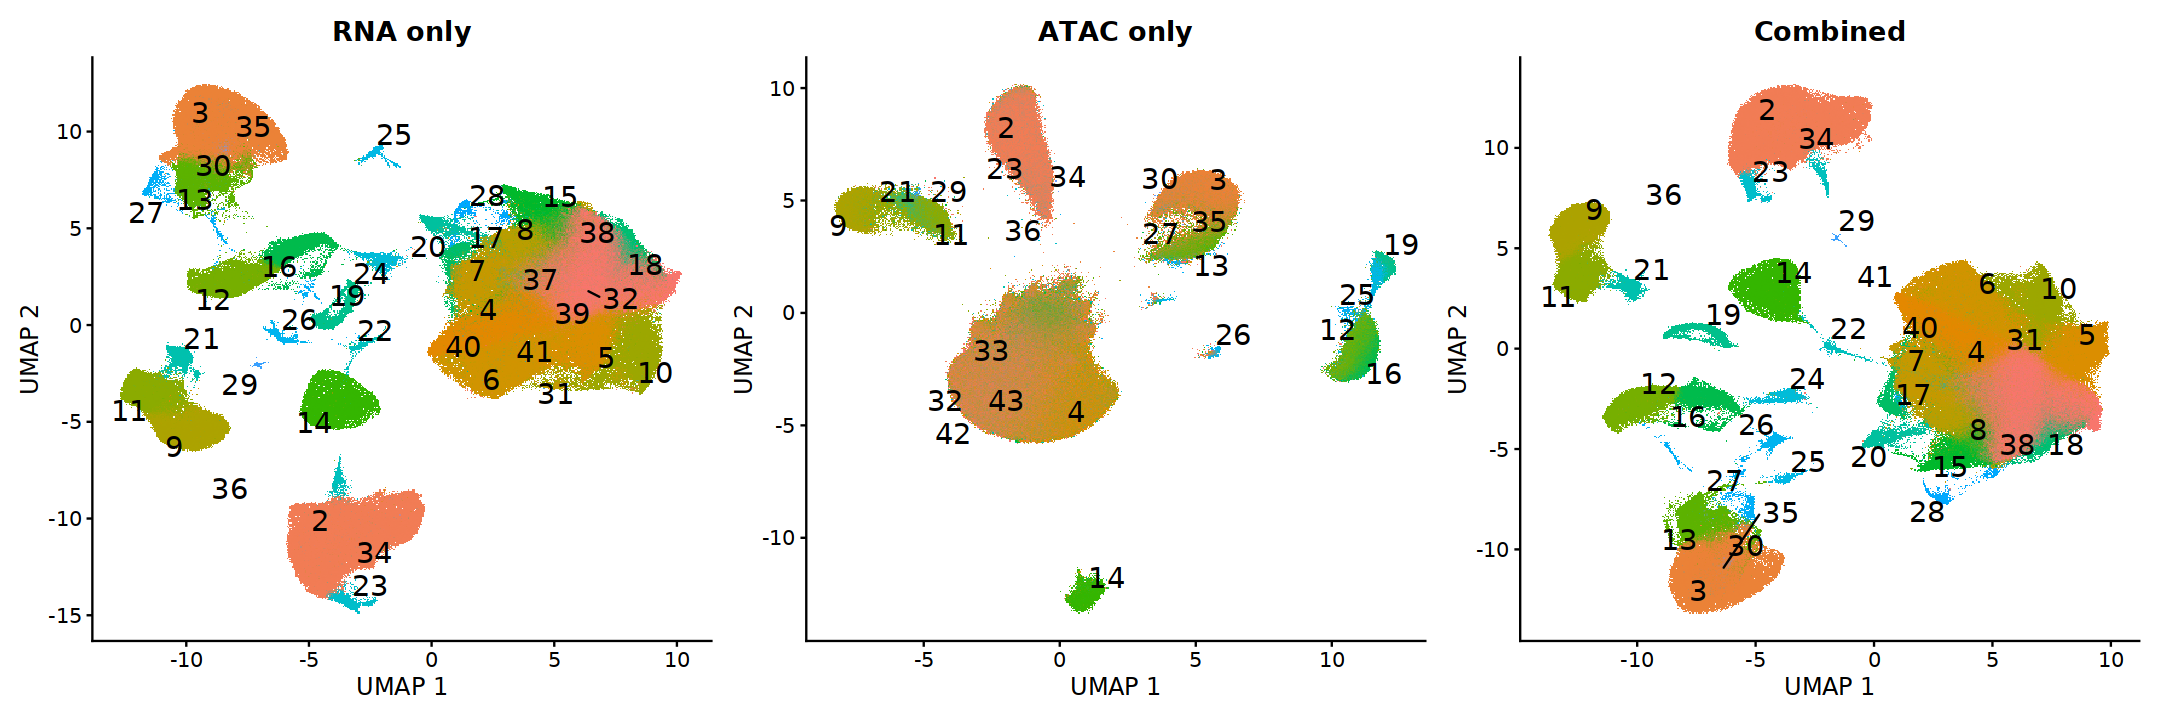

In [14]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='seurat_clusters', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [15]:
#cell counts per cluster
table(adata$seurat_clusters)


    1     2     3     4     5     6     7     8     9    10    11    12    13 
91384 62304 34662 27860 21204 19836 19060 16483 16412 15694 13653 12366 11215 
   14    15    16    17    18    19    20    21    22    23    24    25    26 
10785 10636  8202  5390  4314  3864  3500  3099  2649  2132  1906  1740  1738 
   27    28    29    30    31    32    33    34    35    36    37    38    39 
 1482  1273   462   219     3     2     2     2     2     2     2     2     2 
   40    41    42    43 
    2     2     2     2 


Attaching package: 'tidyr'


The following objects are masked from 'package:Matrix':

    expand, pack, unpack


The following object is masked from 'package:S4Vectors':

    expand




In [28]:
adata_sub <- subset(adata, idents = as.character(1:30))
adata_sub

An object of class Seurat 
157583 features across 425524 samples within 4 assays 
Active assay: windows (50000 features, 50000 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [18]:
#This is the marker gene list that has 3 each and the additional cell types we discovered last time. 
# reLoad marker list that has additional cell types and compartment 
#CHANGE file name 
# paste means con
cell.markers = read.table("/nfs/lab/scorban/fnih_liver_231110/intregration/assests/Liver.Marker.Gene.List.3only_2.txt", sep = "\t", header = TRUE)
# Make it long, remove useless column and void markers
cell.markers <- cell.markers %>% gather(Key, marker, c(3:ncol(cell.markers)))
cell.markers = cell.markers[,-3]
cell.markers = cell.markers[cell.markers$marker != "", ]


# Factorize columns -- creating an order of the cells for the graphs 
cell.markers$Compartment = factor(cell.markers$Compartment, 
                        levels = c("Liver", "Immune", "Vascular", "Stromal", "Other"))
cell.markers$CellType = factor(cell.markers$CellType,
                        levels = c("Hepatoblasts", "Hepatocyte", "Cholangiocyte", "Hepatic_stellate_cell", "Kupffer_cell", 
                                   "Macrophage", "Myeloid", "B_cell", "Mast", "DC", "Plasma", "T_cell-NK", "T_cell", "NK", 
                                   "Endothelial", "Lymph-Endo", 
                                   "Fibroblast", "Adipocyte", "Myofibroblast", 
                                   "Erythrocytes"))

cell.compartment = cell.markers[,-3]

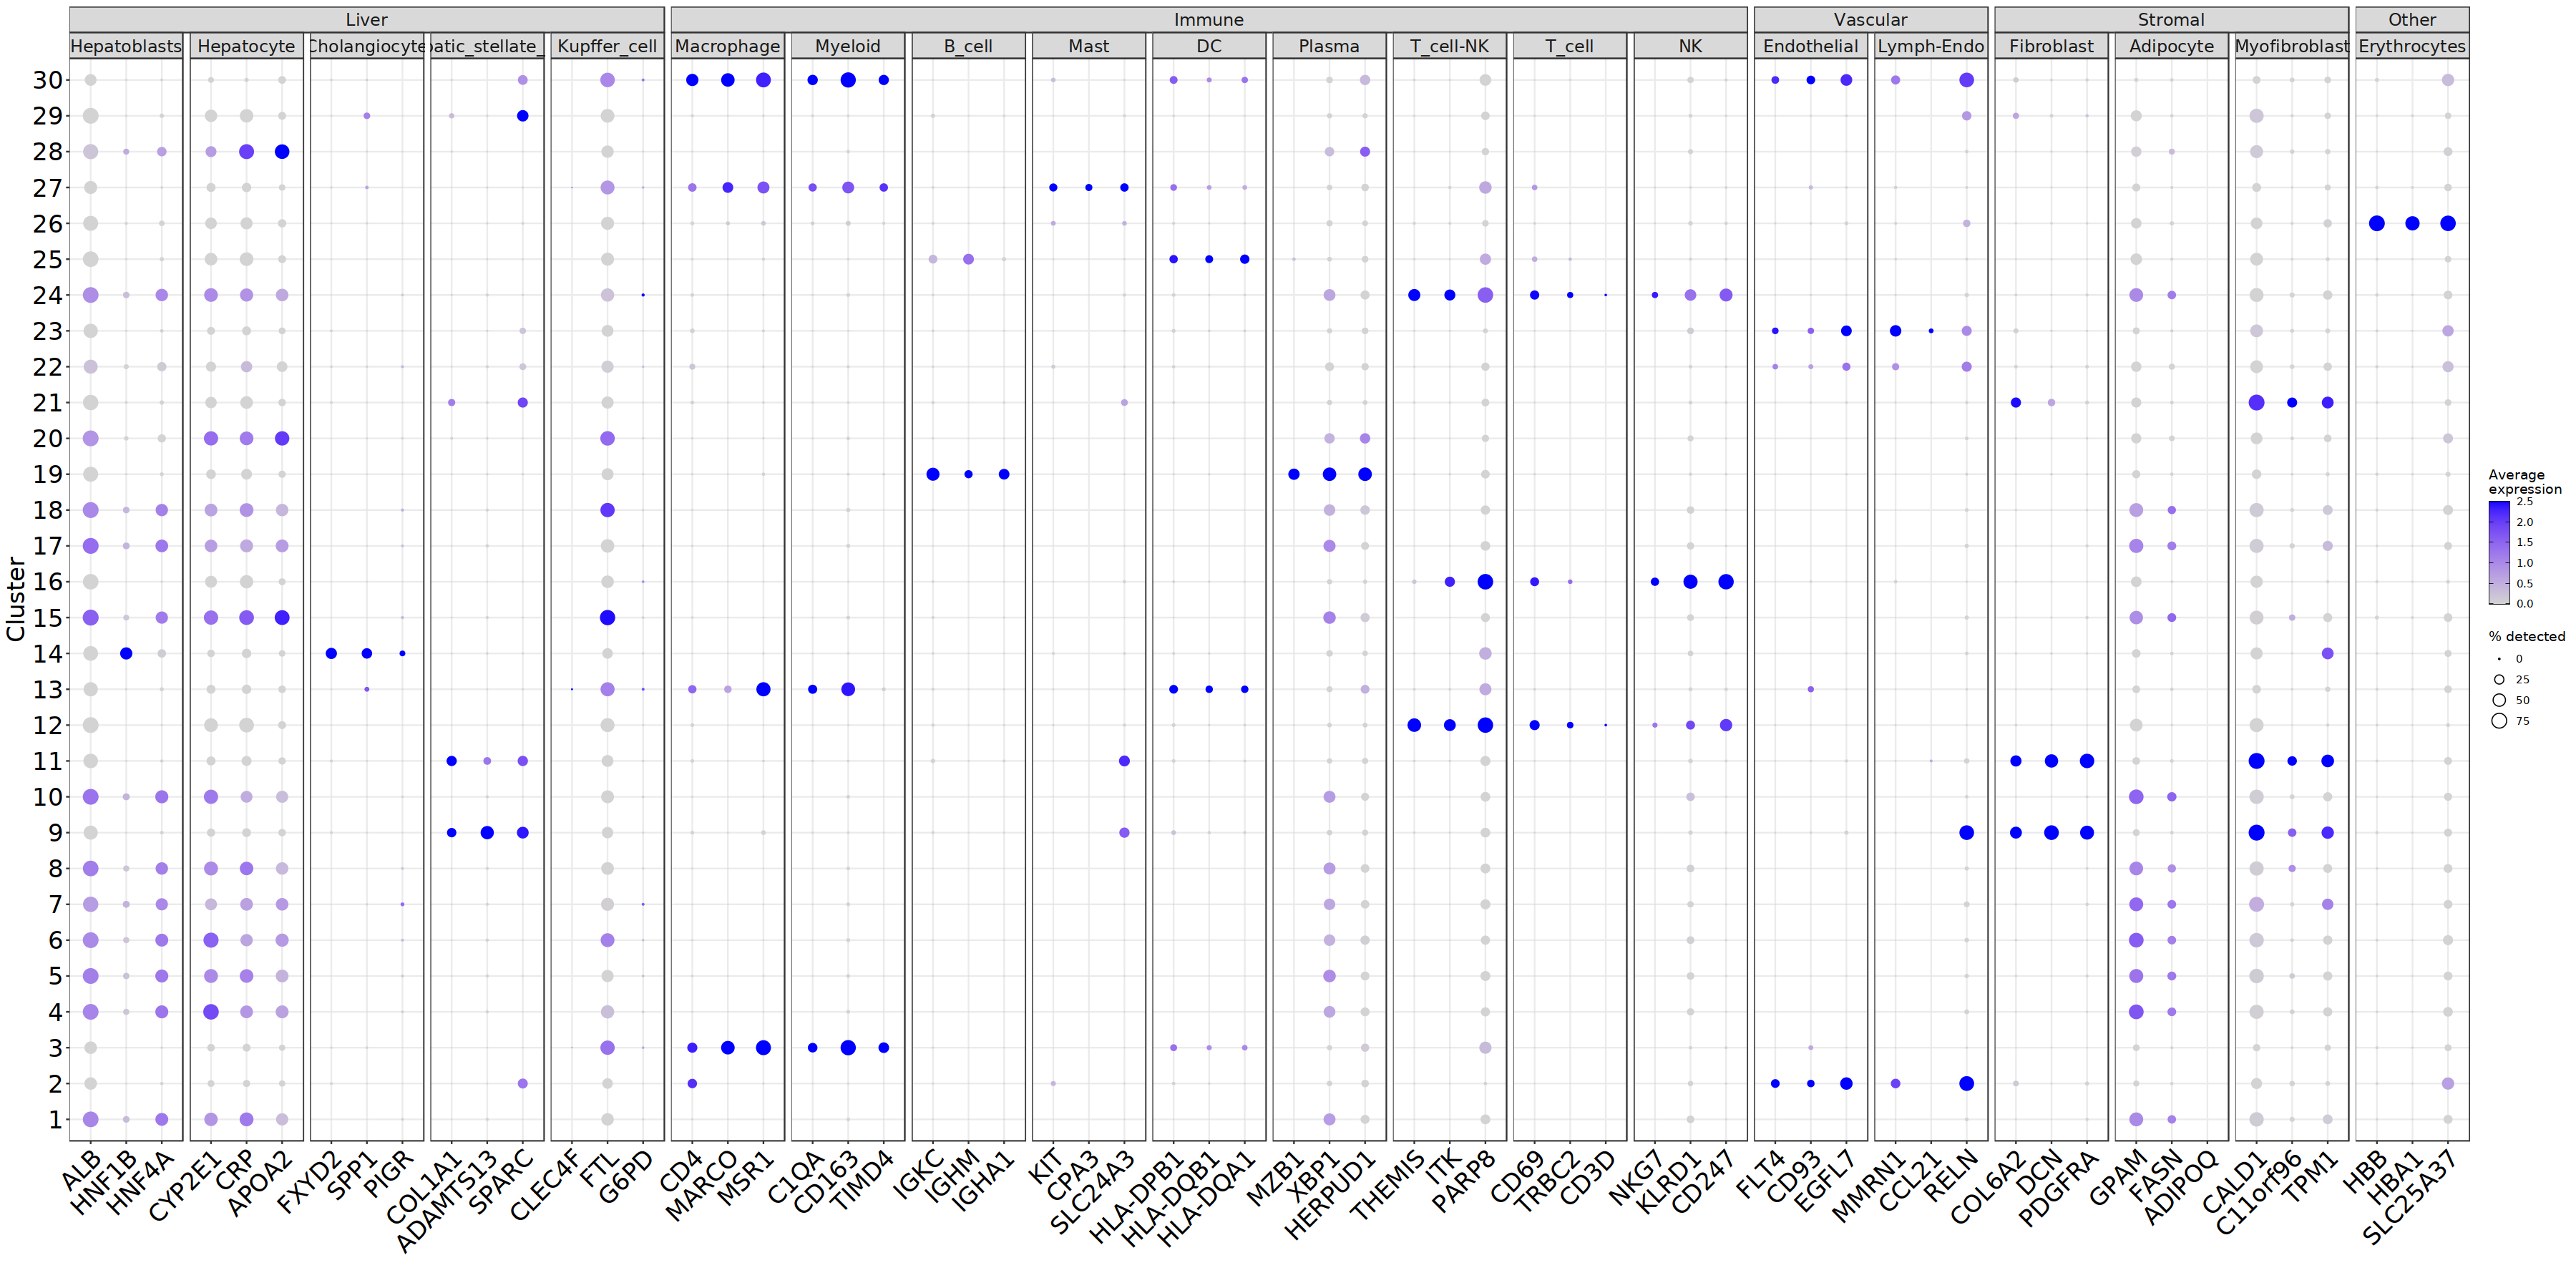

In [29]:
#Making a dot plot with cell type markers. We will use this to not only assign cell types, but also narrow down the markers, since I have too many liver marker genes.
#Change width and height, since I'll have so many markers to visualize. (previous width/height was 25/10).
g = DotPlot(adata_sub, assay='SCT', features=cell.markers$marker, cluster.idents=FALSE, col.min=0) +
        theme(axis.text.x=element_text(angle=45, hjust=1)) + xlab('') + ylab('')
    meta_summary = g$data
    colnames(meta_summary)[3] = "marker"
    meta_summary = merge(meta_summary, cell.markers, by = "marker")

    options(repr.plot.width=30, repr.plot.height=15)
    figure <- ggplot(meta_summary, aes(x = marker, y = id)) +
      geom_point(aes(size = pct.exp, fill = avg.exp.scaled, stroke=NA),
                 shape = 21) +
      scale_size("% detected", range = c(0, 6)) +
      scale_fill_gradient(low = "lightgray", high = "blue",
                           guide = guide_colorbar(nbin = 200,
                                                  ticks.colour = "black", frame.colour = "black"),
                           name = "Average\nexpression") +
      ylab("Cluster") + xlab("") +
      theme_bw() +
      theme(axis.text = element_text(size = 100),
            axis.text.x = element_text(size = 20, angle = 45, hjust = 1, color = "black"),
            strip.text.x = element_text(size = 14),
            axis.text.y = element_text(size = 20, color = "black"),
            axis.title = element_text(size = 20)) +
      facet_nested(cols = vars(Compartment, CellType), scales = "free", space = "free")
figure

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



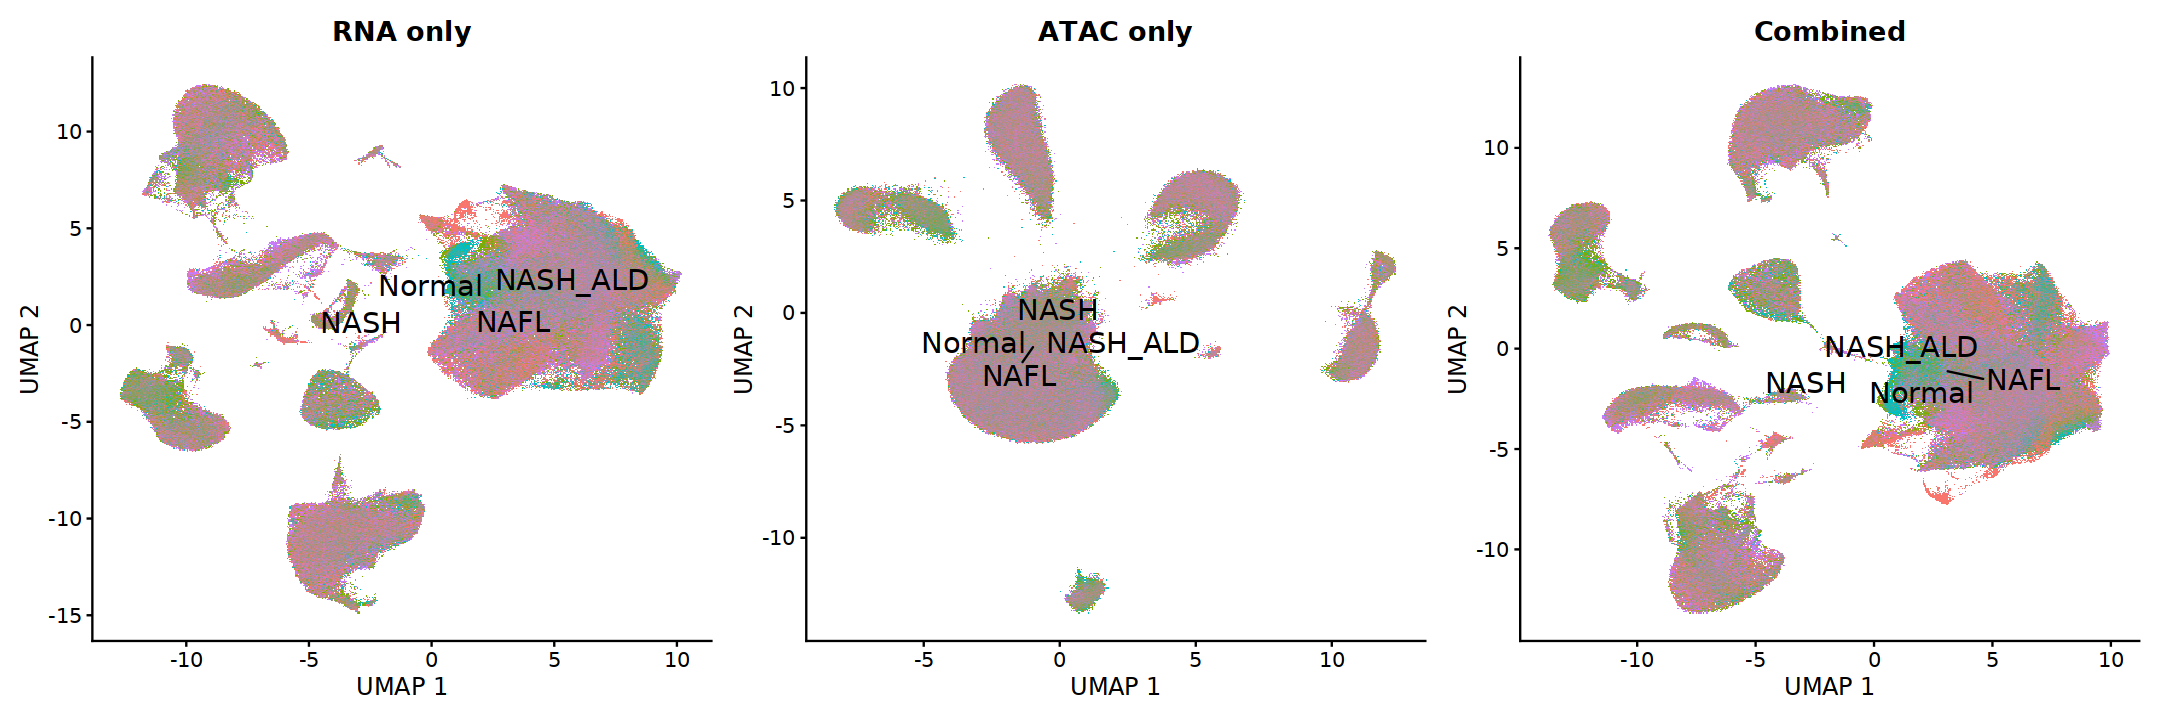

In [31]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='condition', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='condition', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='condition', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



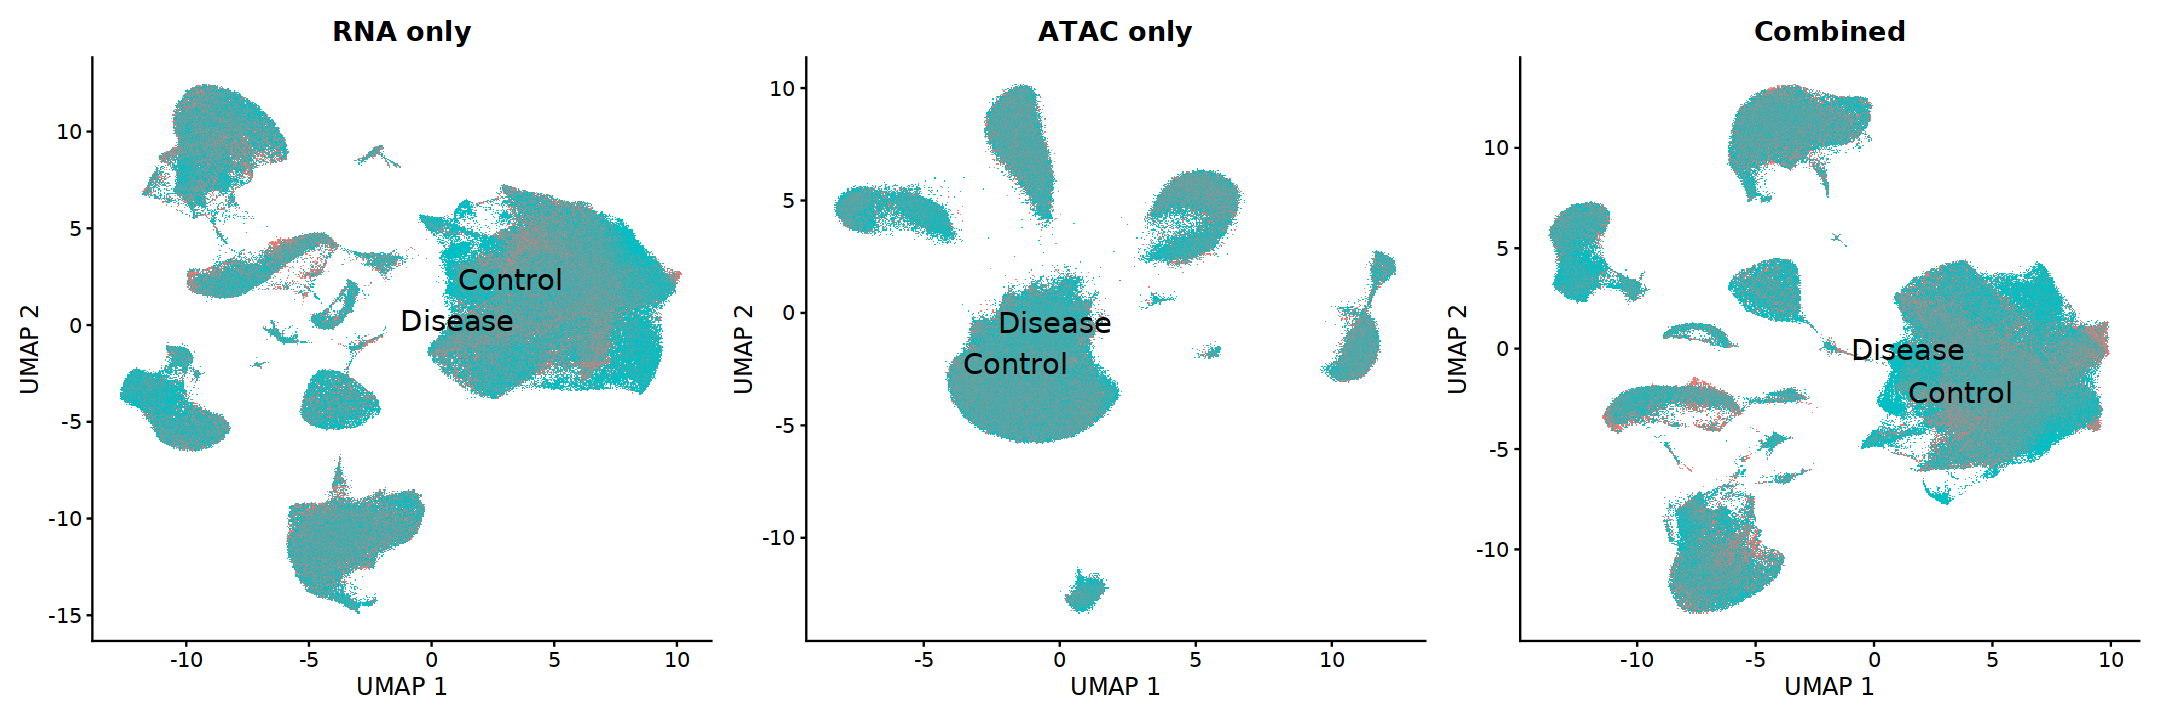

In [32]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='disease_status', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='disease_status', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='disease_status', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



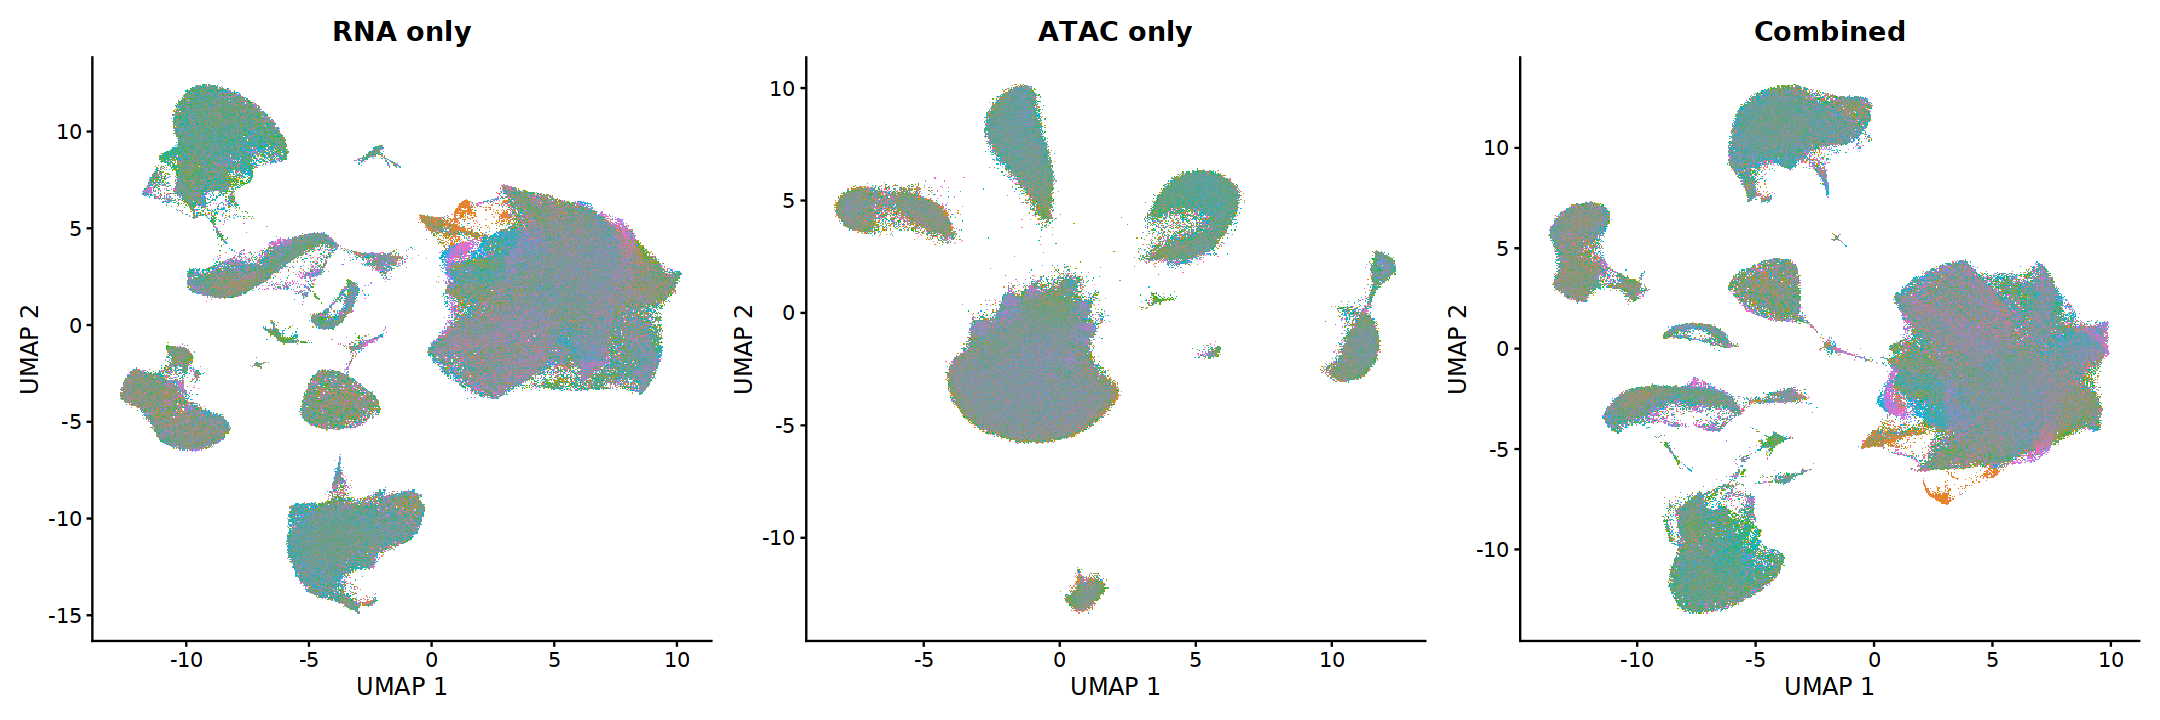

In [33]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='library', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='library', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='library', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



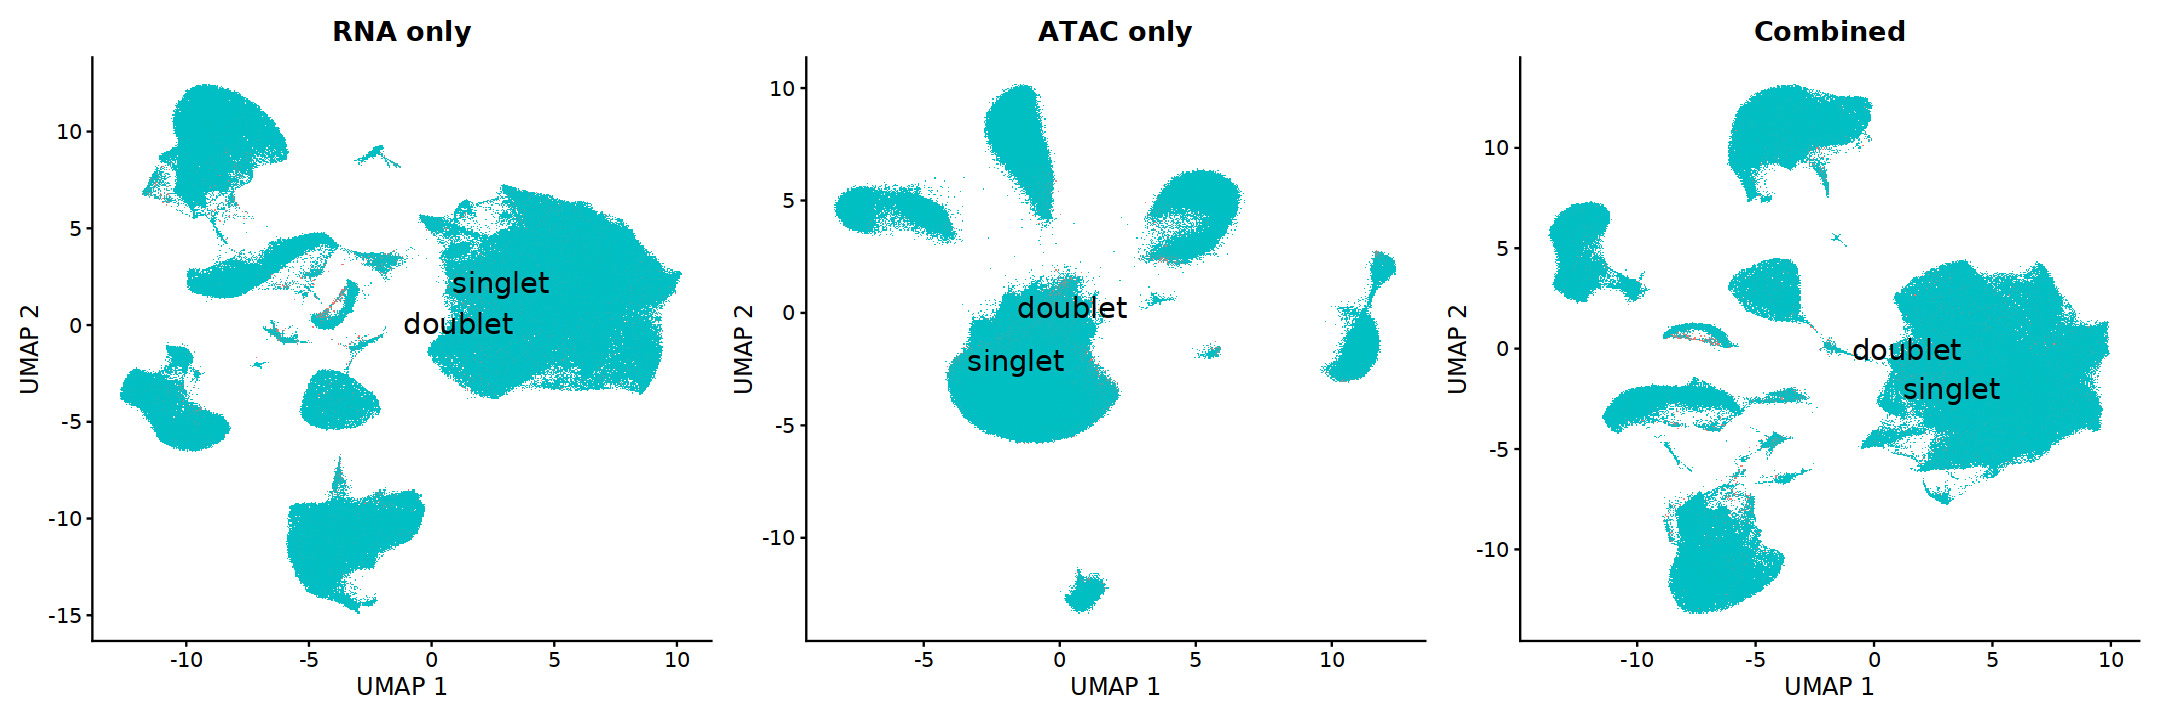

In [34]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='amulet', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='amulet', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='amulet', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



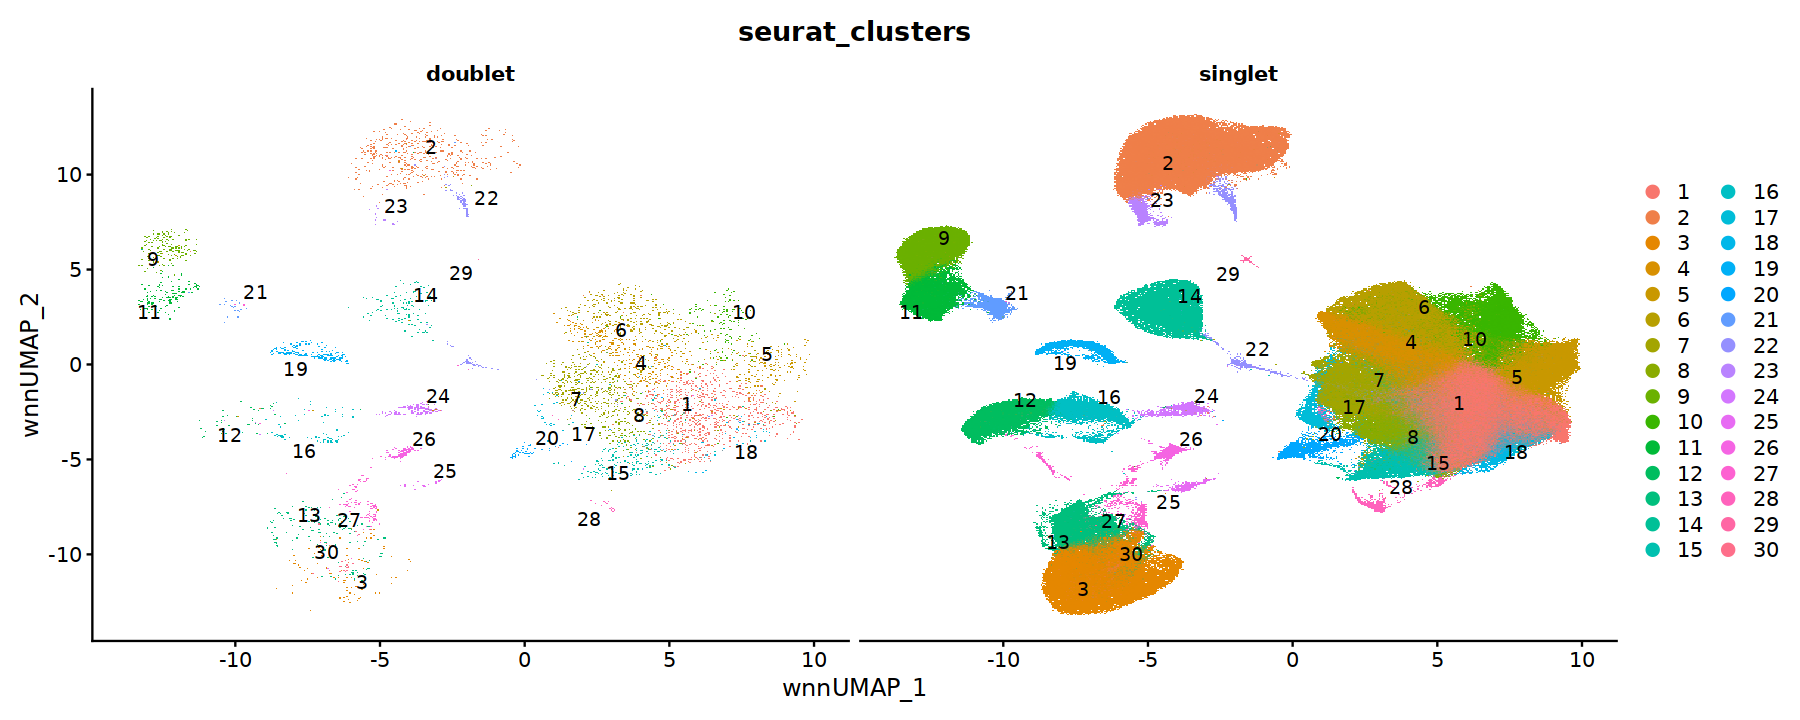

In [55]:
options(repr.plot.width=15, repr.plot.height=6)
p1 <- DimPlot(adata_sub, reduction='umap.wnn', group.by='seurat_clusters', split.by='amulet', label=TRUE, label.size=4, repel=TRUE)
p1

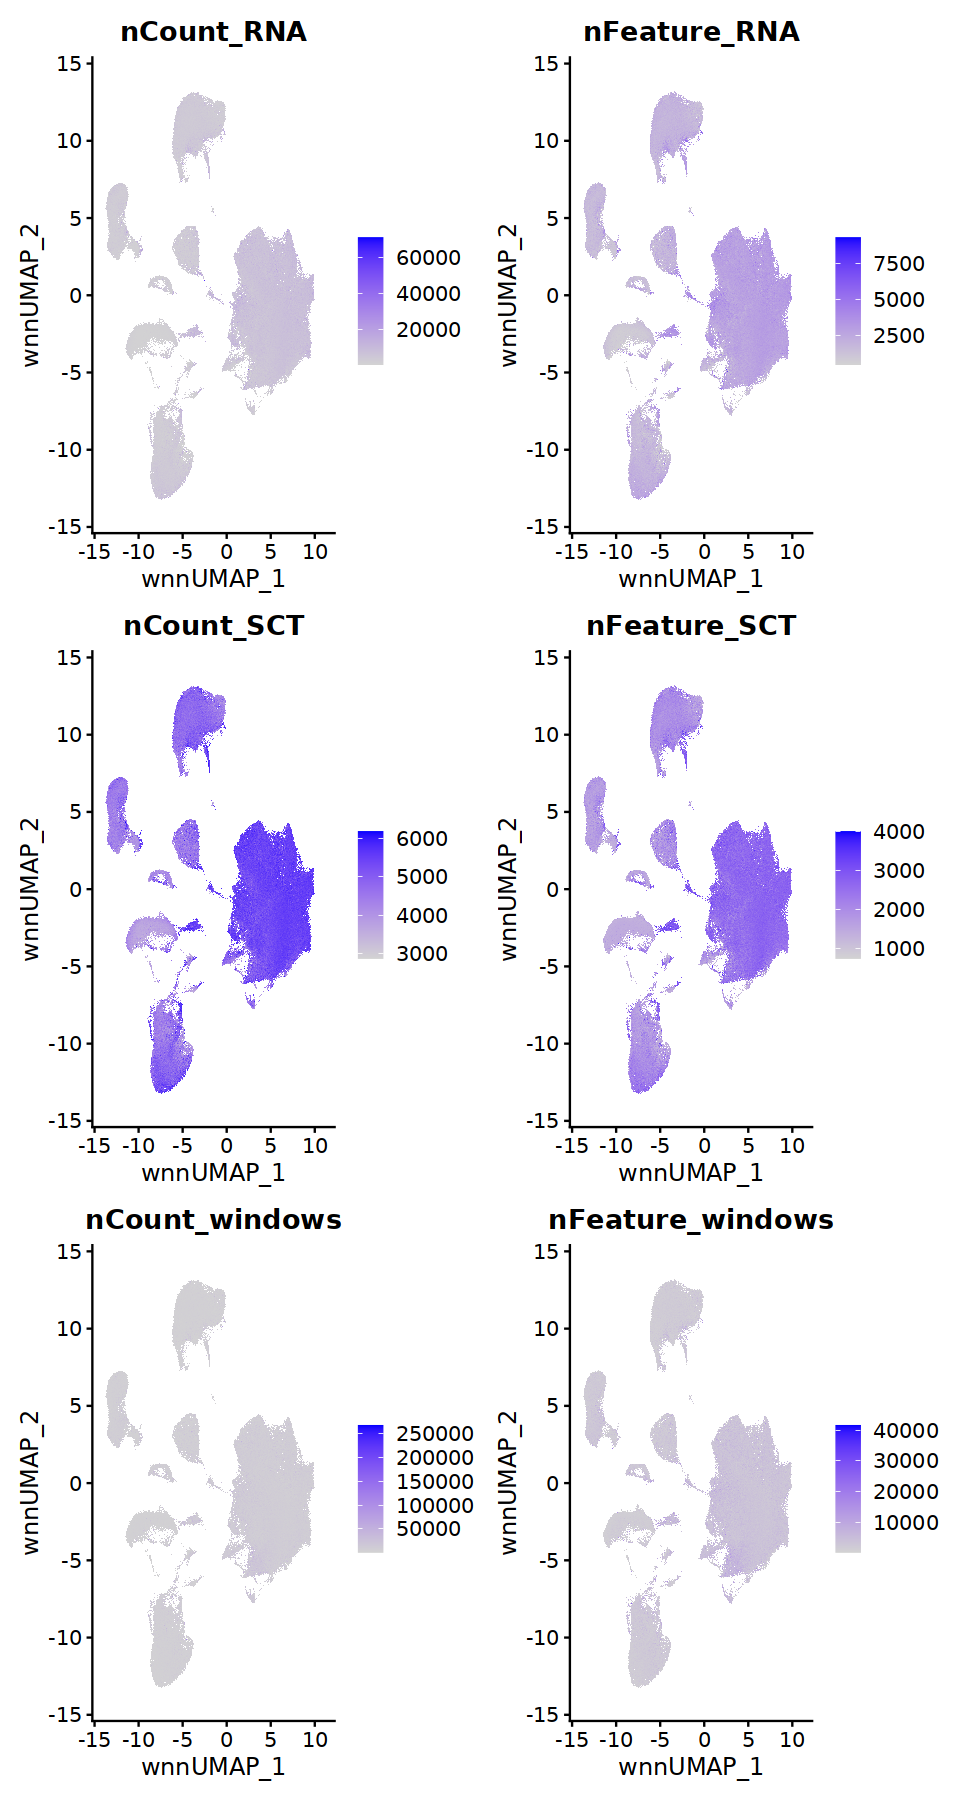

In [257]:
options(repr.plot.width=8, repr.plot.height=15)
FeaturePlot(
  object = adata_sub,
  reduction = "umap.wnn",
  features = c('nCount_RNA', 'nFeature_RNA',
              'nCount_SCT','nFeature_SCT',
              'nCount_windows','nFeature_windows'),
  ncol = 2,
  raster=TRUE
)

In [42]:
table(adata_sub[[]][c('seurat_clusters','amulet')])

               amulet
seurat_clusters doublet singlet
             1      848   90536
             2      497   61807
             3       92   34570
             4      352   27508
             5      294   20910
             6      337   19499
             7      482   18578
             8      168   16315
             9      157   16255
             10     162   15532
             11     152   13501
             12      38   12328
             13     177   11038
             14     120   10665
             15     236   10400
             16      80    8122
             17      48    5342
             18      30    4284
             19     217    3647
             20      57    3443
             21      25    3074
             22     201    2448
             23      17    2115
             24     158    1748
             25      23    1717
             26     174    1564
             27     128    1354
             28      15    1258
             29       2     460
             30   

In [56]:
table(adata_sub[[]][c('seurat_clusters','amulet')])[,1] * 100 / table(adata_sub[[]][c('seurat_clusters','amulet')])[,2]

1          2          3          4          5          6          7 
 0.9366440  0.8041160  0.2661267  1.2796277  1.4060258  1.7282938  2.5944666 
         8          9         10         11         12         13         14 
 1.0297272  0.9658567  1.0430080  1.1258425  0.3082414  1.6035514  1.1251758 
        15         16         17         18         19         20         21 
 2.2692308  0.9849791  0.8985399  0.7002801  5.9500960  1.6555330  0.8132726 
        22         23         24         25         26         27         28 
 8.2107843  0.8037825  9.0389016  1.3395457 11.1253197  9.4534712  1.1923688 
        29         30         31         32         33         34         35 
 0.4347826 13.4715026        NaN        NaN        NaN        NaN        NaN 
        36         37         38         39         40         41         42 
       NaN        NaN        NaN        NaN        NaN        NaN        NaN 
        43 
       NaN

In [35]:
c('Hepatocyte','Endothelial','Macrophage','Hepatocyte','Hepatocyte',
'Hepatocyte','Hepatocyte','Hepatocyte','Hepatic_Stellate','Hepatocyte',
'Hepatic_Stellate','T_cells','DC','Cholangiocyte','Hepatocyte',
'NK','Hepatocyte','Hepatocyte','B_cells','Hepatocyte',
'Myofibroblasts','Endothelial','Endothelial','T_cells','DC',
'Erythrocytes','Mast','Hepatocyte','Uknown','Macrophage')

[1] "Hepatocyte"       "Endothelial"      "Macrophage"       "Hepatocyte"      
 [5] "Hepatocyte"       "Hepatocyte"       "Hepatocyte"       "Hepatocyte"      
 [9] "Hepatic_Stellate" "Hepatocyte"       "Hepatic_Stellate" "T_cells"         
[13] "DC"               "Cholangiocyte"    "Hepatocyte"       "NK"              
[17] "Hepatocyte"       "Hepatocyte"       "B_cells"          "Hepatocyte"      
[21] "Myofibroblasts"   "Endothelial"      "Endothelial"      "T_cells"         
[25] "DC"               "Erythrocytes"     "Mast"             "Hepatocyte"      
[29] "Uknown"           "Macrophage"

In [36]:
# list cluster numbers as they appear in the dotplot
clusters = 1:30

# visually determine celltypes
celltypes = c('Hepatocyte','Endothelial','Macrophage','Hepatocyte','Hepatocyte',
              'Hepatocyte','Hepatocyte','Hepatocyte','Hepatic_Stellate','Hepatocyte',
              'Hepatic_Stellate','T_cells','DC','Cholangiocyte','Hepatocyte',
              'NK','Hepatocyte','Hepatocyte','B_cells','Hepatocyte',
              'Myofibroblasts','Endothelial','Endothelial','T_cells','DC',
              'Erythrocytes','Mast','Hepatocyte','Uknown','Macrophage')

length(clusters)
length(celltypes)

clusters.celltypes = data.frame(seurat_clusters = clusters,
                               celltypes = celltypes)

[1] 30

[1] 30

In [37]:
adata_sub <- SetIdent(adata_sub, value = adata_sub$seurat_clusters)
levels(adata_sub)
adata_sub$celltypes <- clusters.celltypes$celltypes[match(adata_sub$seurat_clusters, clusters.celltypes$seurat_clusters)]
adata_sub <- SetIdent(adata_sub, value = adata_sub$celltypes)
levels(adata_sub)

[1] "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "14" "15"
[16] "16" "17" "18" "19" "20" "21" "22" "23" "24" "25" "26" "27" "28" "29" "30"

[1] "Endothelial"      "Hepatocyte"       "T_cells"          "Hepatic_Stellate"
 [5] "Myofibroblasts"   "Cholangiocyte"    "Macrophage"       "Uknown"          
 [9] "DC"               "NK"               "B_cells"          "Mast"            
[13] "Erythrocytes"

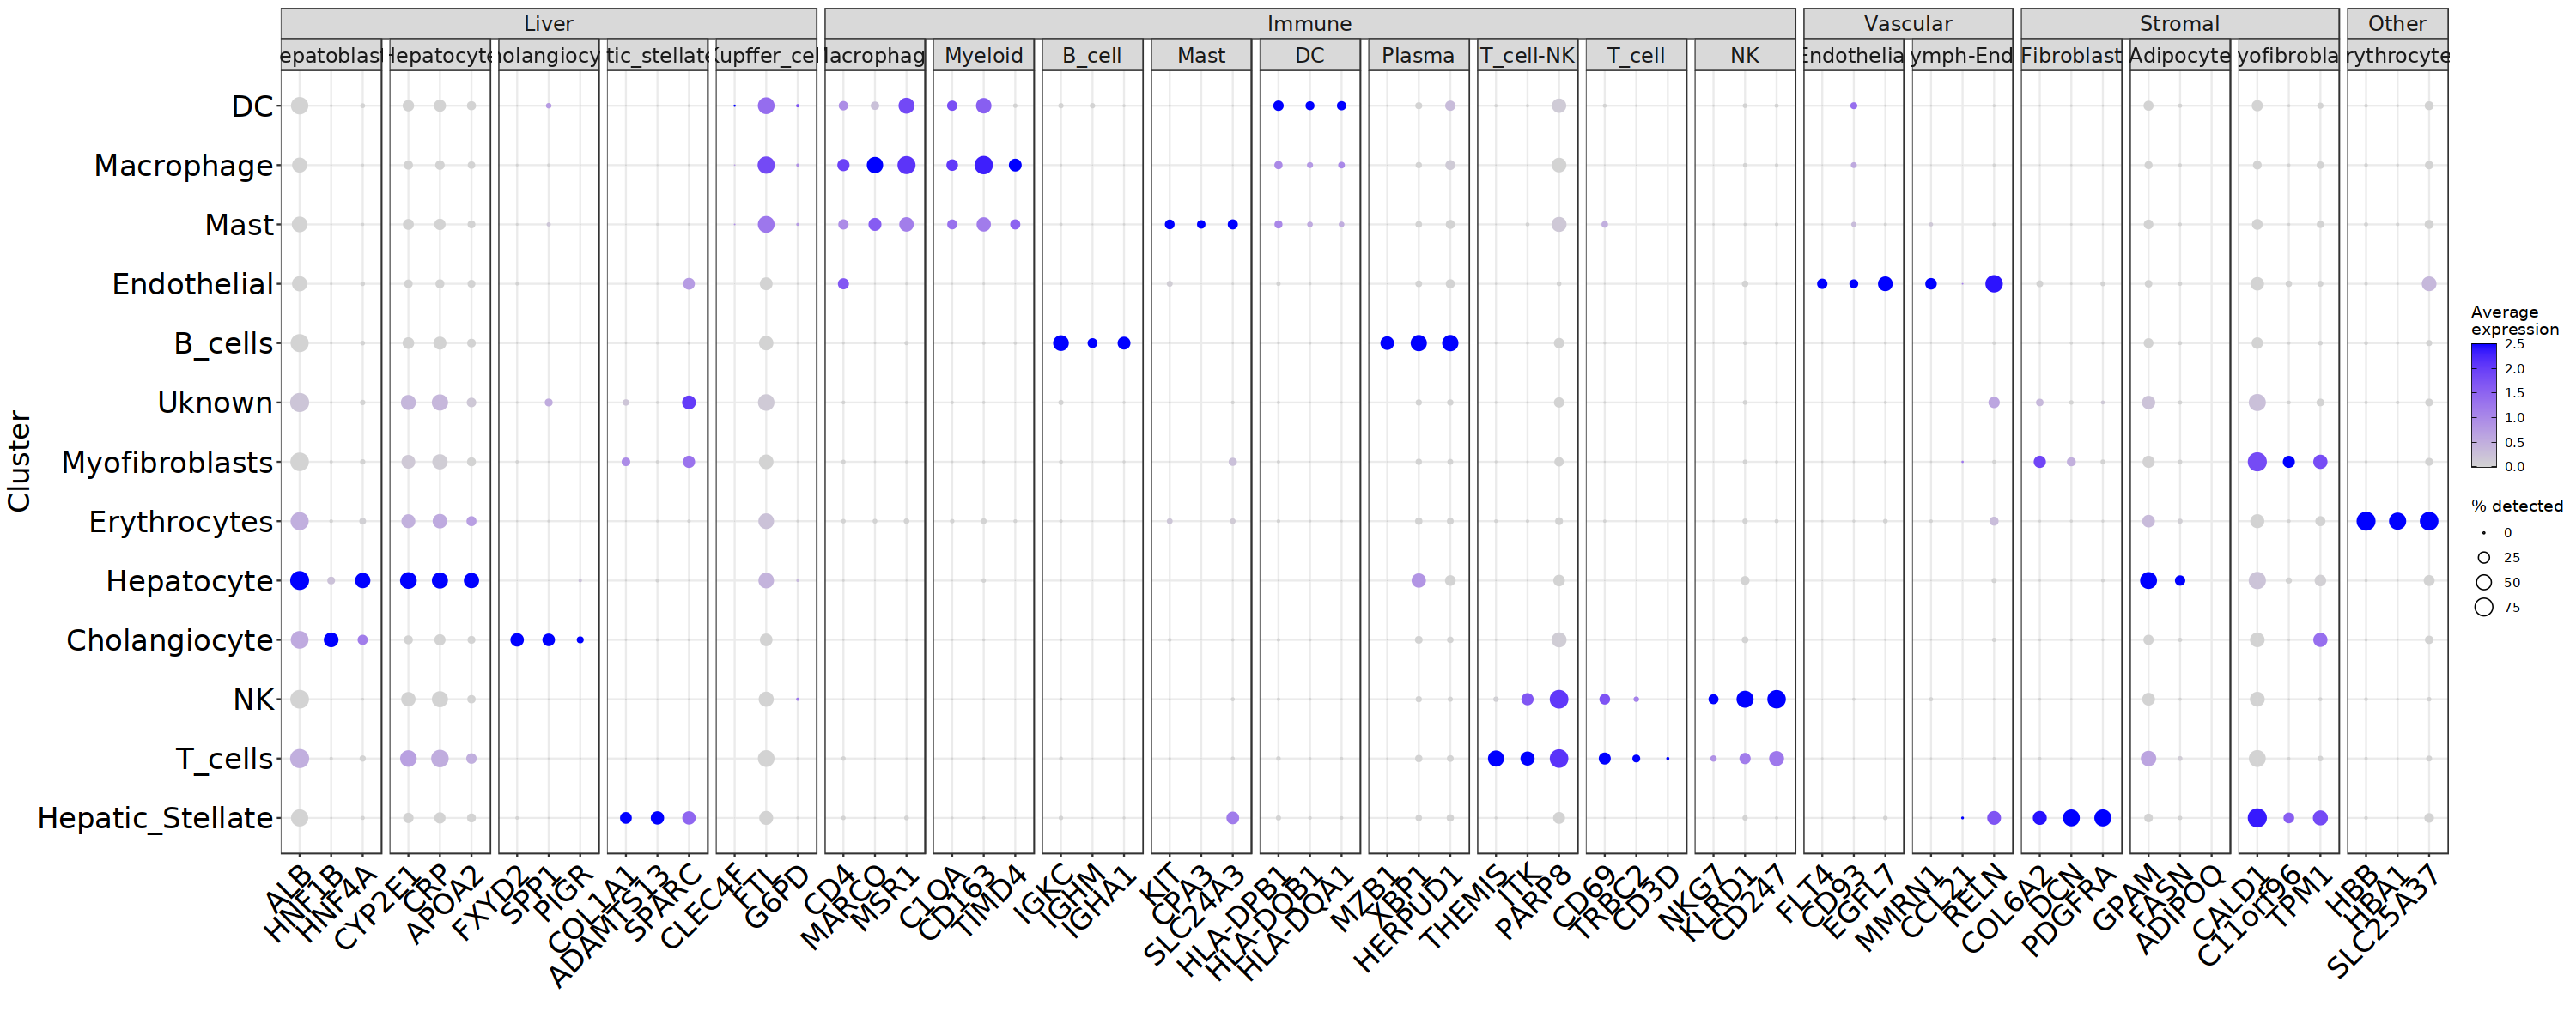

In [38]:
#reMaking a dot plot with cell type markers. We will use this to not only assign cell types, but also narrow down the markers, since I have too many liver marker genes.
#Change width and height, since I'll have so many markers to visualize. (previous width/height was 25/10).
g = DotPlot(adata_sub, assay='SCT', features=cell.markers$marker, cluster.idents=TRUE, col.min=0) +
        theme(axis.text.x=element_text(angle=45, hjust=1)) + xlab('') + ylab('')
    meta_summary = g$data
    colnames(meta_summary)[3] = "marker"
    meta_summary = merge(meta_summary, cell.markers, by = "marker")

    options(repr.plot.width=25, repr.plot.height=10)
    figure <- ggplot(meta_summary, aes(x = marker, y = id)) +
      geom_point(aes(size = pct.exp, fill = avg.exp.scaled, stroke=NA),
                 shape = 21) +
      scale_size("% detected", range = c(0, 6)) +
      scale_fill_gradient(low = "lightgray", high = "blue",
                           guide = guide_colorbar(nbin = 200,
                                                  ticks.colour = "black", frame.colour = "black"),
                           name = "Average\nexpression") +
      ylab("Cluster") + xlab("") +
      theme_bw() +
      theme(axis.text = element_text(size = 100),
            axis.text.x = element_text(size = 20, angle = 45, hjust = 1, color = "black"),
            strip.text.x = element_text(size = 14),
            axis.text.y = element_text(size = 20, color = "black"),
            axis.title = element_text(size = 20)) +
      facet_nested(cols = vars(Compartment, CellType), scales = "free", space = "free")
figure

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



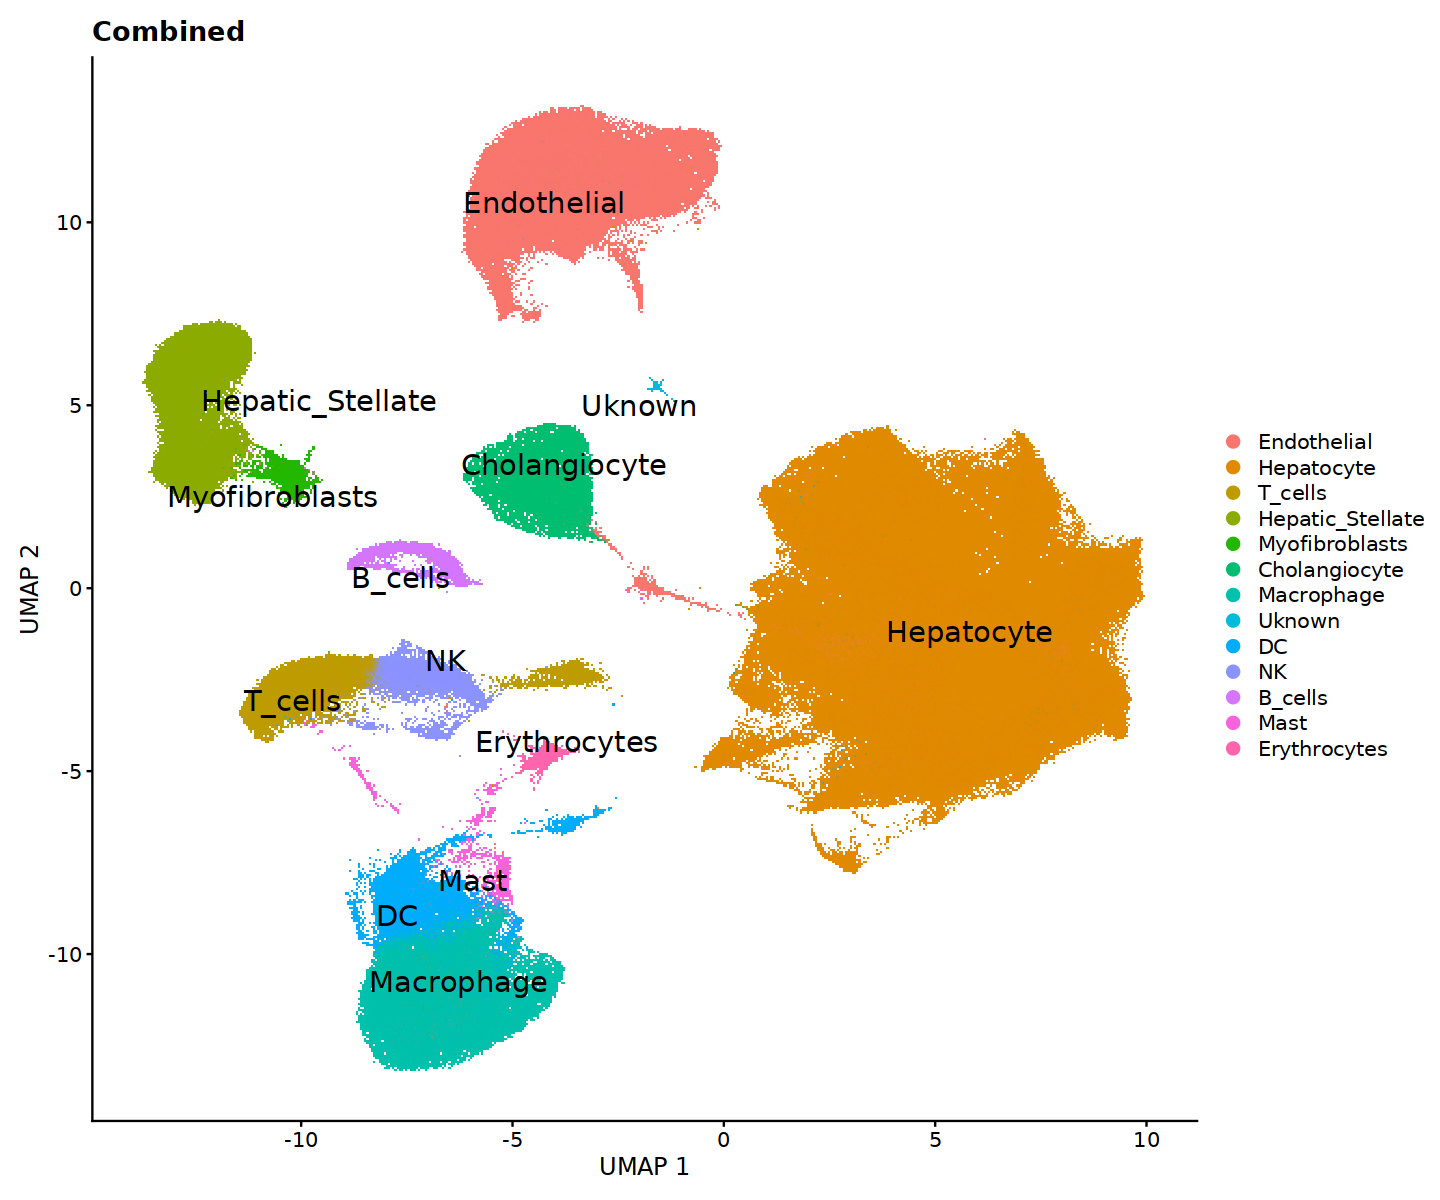

In [39]:
options(repr.plot.width=12, repr.plot.height=10)
DimPlot(adata_sub, reduction='umap.wnn', label=TRUE, label.size=6, repel=TRUE) +
ggtitle('WNN') + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



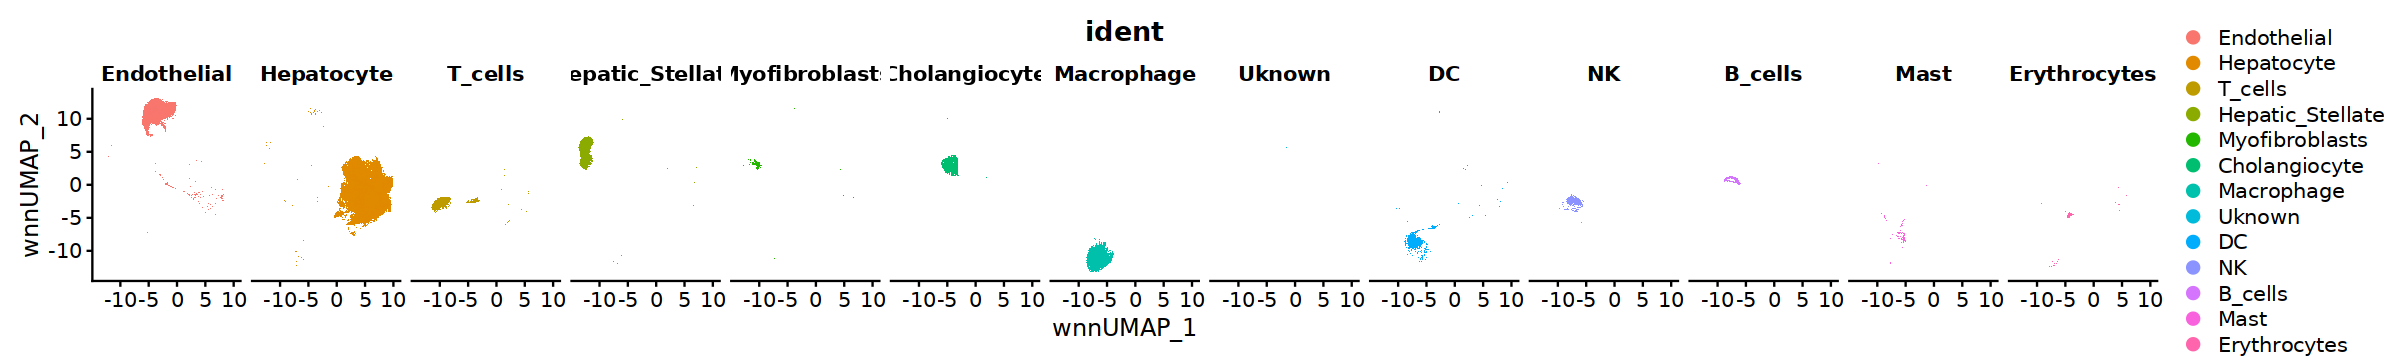

In [40]:
options(repr.plot.width=20, repr.plot.height=3)
p1 <- DimPlot(adata_sub, reduction='umap.wnn', group.by='ident', split.by='ident', label=FALSE, label.size=20, repel=TRUE)
p1

In [41]:
table(Idents(adata_sub))


     Endothelial       Hepatocyte          T_cells Hepatic_Stellate 
           67085           236634            14272            30065 
  Myofibroblasts    Cholangiocyte       Macrophage           Uknown 
            3099            10785            34881              462 
              DC               NK          B_cells             Mast 
           12955             8202             3864             1482 
    Erythrocytes 
            1738 

In [43]:
table(adata_sub[[]][c('seurat_clusters','amulet')])

               amulet
seurat_clusters doublet singlet
             1      848   90536
             2      497   61807
             3       92   34570
             4      352   27508
             5      294   20910
             6      337   19499
             7      482   18578
             8      168   16315
             9      157   16255
             10     162   15532
             11     152   13501
             12      38   12328
             13     177   11038
             14     120   10665
             15     236   10400
             16      80    8122
             17      48    5342
             18      30    4284
             19     217    3647
             20      57    3443
             21      25    3074
             22     201    2448
             23      17    2115
             24     158    1748
             25      23    1717
             26     174    1564
             27     128    1354
             28      15    1258
             29       2     460
             30   

In [46]:
table(adata_sub[[]][c('seurat_clusters','amulet')])[,1] * 100 / table(adata_sub[[]][c('seurat_clusters','amulet')])[,2]a

1          2          3          4          5          6          7 
 0.9366440  0.8041160  0.2661267  1.2796277  1.4060258  1.7282938  2.5944666 
         8          9         10         11         12         13         14 
 1.0297272  0.9658567  1.0430080  1.1258425  0.3082414  1.6035514  1.1251758 
        15         16         17         18         19         20         21 
 2.2692308  0.9849791  0.8985399  0.7002801  5.9500960  1.6555330  0.8132726 
        22         23         24         25         26         27         28 
 8.2107843  0.8037825  9.0389016  1.3395457 11.1253197  9.4534712  1.1923688 
        29         30         31         32         33         34         35 
 0.4347826 13.4715026        NaN        NaN        NaN        NaN        NaN 
        36         37         38         39         40         41         42 
       NaN        NaN        NaN        NaN        NaN        NaN        NaN 
        43 
       NaN

In [48]:
adata_sub$ct <- Idents(adata_sub)

In [49]:
table(adata_sub[[]][c('ct','amulet')])[,1] * 100 / table(adata_sub[[]][c('ct','amulet')])[,2]

Endothelial       Hepatocyte          T_cells Hepatic_Stellate 
       1.0772940        1.2966332        1.3924410        1.0384460 
  Myofibroblasts    Cholangiocyte       Macrophage           Uknown 
       0.8132726        1.1251758        0.3394414        0.4347826 
              DC               NK          B_cells             Mast 
       1.5680125        0.9849791        5.9500960        9.4534712 
    Erythrocytes 
      11.1253197

In [57]:
adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 1, verbose=TRUE, method = 'igraph',
                     cluster.name='wnn_res1')

933 singletons identified. 53 final clusters.



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



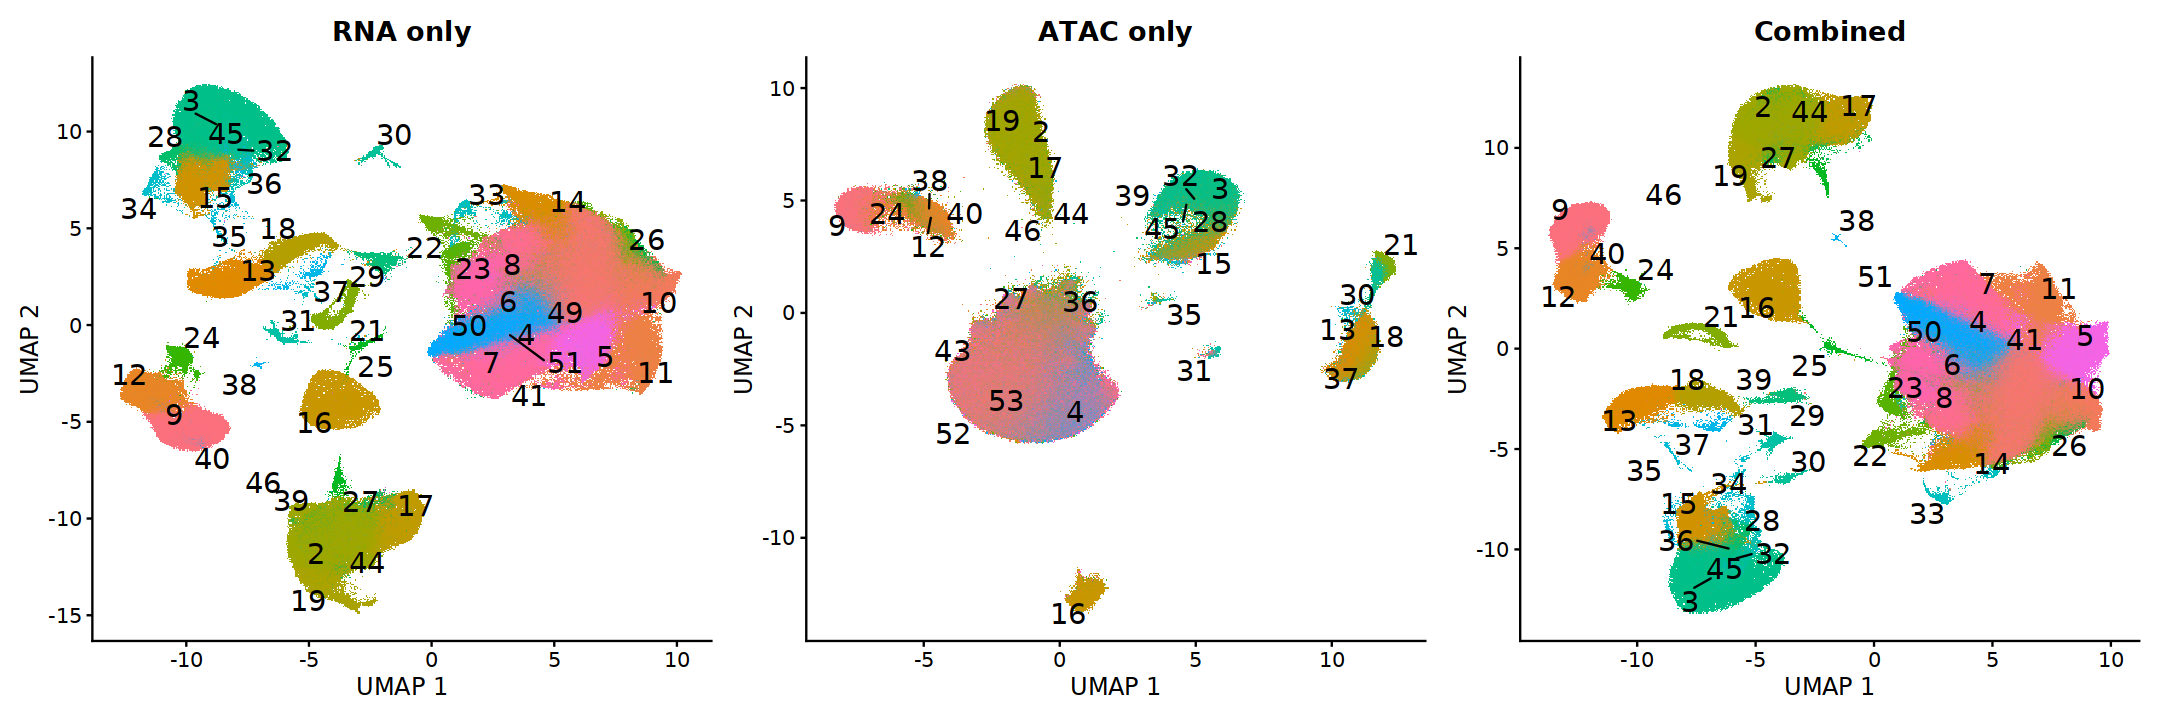

In [61]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='wnn_res1', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='wnn_res1', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='wnn_res1', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [60]:
#cell counts per cluster
table(adata$wnn_res1)


    1    10    11    12    13    14    15    16    17    18    19     2    20 
69000 15820 15506 13544 12180 11322 10847 10781  9957  7818  7530 44241  6197 
   21    22    23    24    25    26    27    28    29     3    30    31    32 
 3864  3628  3211  3104  2670  2584  2502  1973  1901 30443  1738  1733  1725 
   33    34    35    36    37    38    39     4    40    41    42    43    44 
 1207  1148   625   606   568   462   431 29233   305     3     2     2     2 
   45    46    47    48    49     5    50    51    52    53     6     7     8 
    2     2     2     2     2 22486     2     2     2     2 20250 19878 16291 
    9 
16215 

In [62]:
saveRDS(adata, '/nfs/lab/projects/nash_nafld_liver/keep_demux/06052024_fnih_liver_ALL28lanes_ALL87donors_50kHVWsby16pool_HarmonyCovariates_DonorDemuxAndPoolingBatch_filtered_amulet_high_res.rds')


In [5]:
adata <- readRDS('/nfs/lab/projects/nash_nafld_liver/keep_demux/06052024_fnih_liver_ALL28lanes_ALL87donors_50kHVWsby16pool_HarmonyCovariates_DonorDemuxAndPoolingBatch_filtered_amulet_high_res.rds')
adata

An object of class Seurat 
157583 features across 425551 samples within 4 assays 
Active assay: windows (50000 features, 50000 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [6]:
bp_dir_base <- '/nfs/lab/welison/Liver/Intermediates/240620_WE_Liver_Subclustering_BP_Cells/'

In [7]:
adata[["windows"]] <- as(adata[["windows"]], "Assay5")

adata
object.size(adata)

write_matrix_dir(mat = adata[["windows"]]$counts, dir = paste0(bp_dir_base,"windows_counts"), overwrite = TRUE)
counts.mat <- open_matrix_dir(dir = paste0(bp_dir_base,"windows_counts"))
adata[["windows"]]$counts <- counts.mat


write_matrix_dir(mat = adata[["windows"]]$data, dir = paste0(bp_dir_base,"windows_data"), overwrite = TRUE)
data.mat <- open_matrix_dir(dir = paste0(bp_dir_base,"windows_data"))
adata[["windows"]]$data <- data.mat

gc()

adata

An object of class Seurat 
157583 features across 425551 samples within 4 assays 
Active assay: windows (50000 features, 50000 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

45744057144 bytes

• Consider calling convert_matrix_type if a compressed integer matrix is intended.
This message is displayed once every 8 hours.


50000 x 425551 IterableMatrix object with class MatrixDir

Row names: chr1-1000000-1005000, chr1-10040000-10045000 ... chrY-9995000-10000000
Col names: MM_1341_1_2_MM_1337_1_2_AAACAGCCACAGACTC-1, MM_1341_1_2_MM_1337_1_2_AAACAGCCAGGTTTGC-1 ... QY_2410_2_QY_2409_2_TTTGTTGGTTTGGCTT-1

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /nfs/lab/welison/Liver/Intermediates/240620_WE_Liver_Subclustering_BP_Cells/windows_counts

50000 x 425551 IterableMatrix object with class MatrixDir

Row names: chr1-1000000-1005000, chr1-10040000-10045000 ... chrY-9995000-10000000
Col names: MM_1341_1_2_MM_1337_1_2_AAACAGCCACAGACTC-1, MM_1341_1_2_MM_1337_1_2_AAACAGCCAGGTTTGC-1 ... QY_2410_2_QY_2409_2_TTTGTTGGTTTGGCTT-1

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /nfs/lab/welison/Liver/Intermediates/240620_WE_Liver_Subclustering_BP_Cells/windows_data

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,12351553,659.7,22078542,1179.2,14058447,750.9
Vcells,1535709513,11716.6,9152202128,69825.8,10392679307,79289.9


An object of class Seurat 
157583 features across 425551 samples within 4 assays 
Active assay: windows (50000 features, 50000 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [8]:
adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 2, verbose=TRUE, method = 'igraph',
                     cluster.name='wnn_res2')

933 singletons identified. 70 final clusters.



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



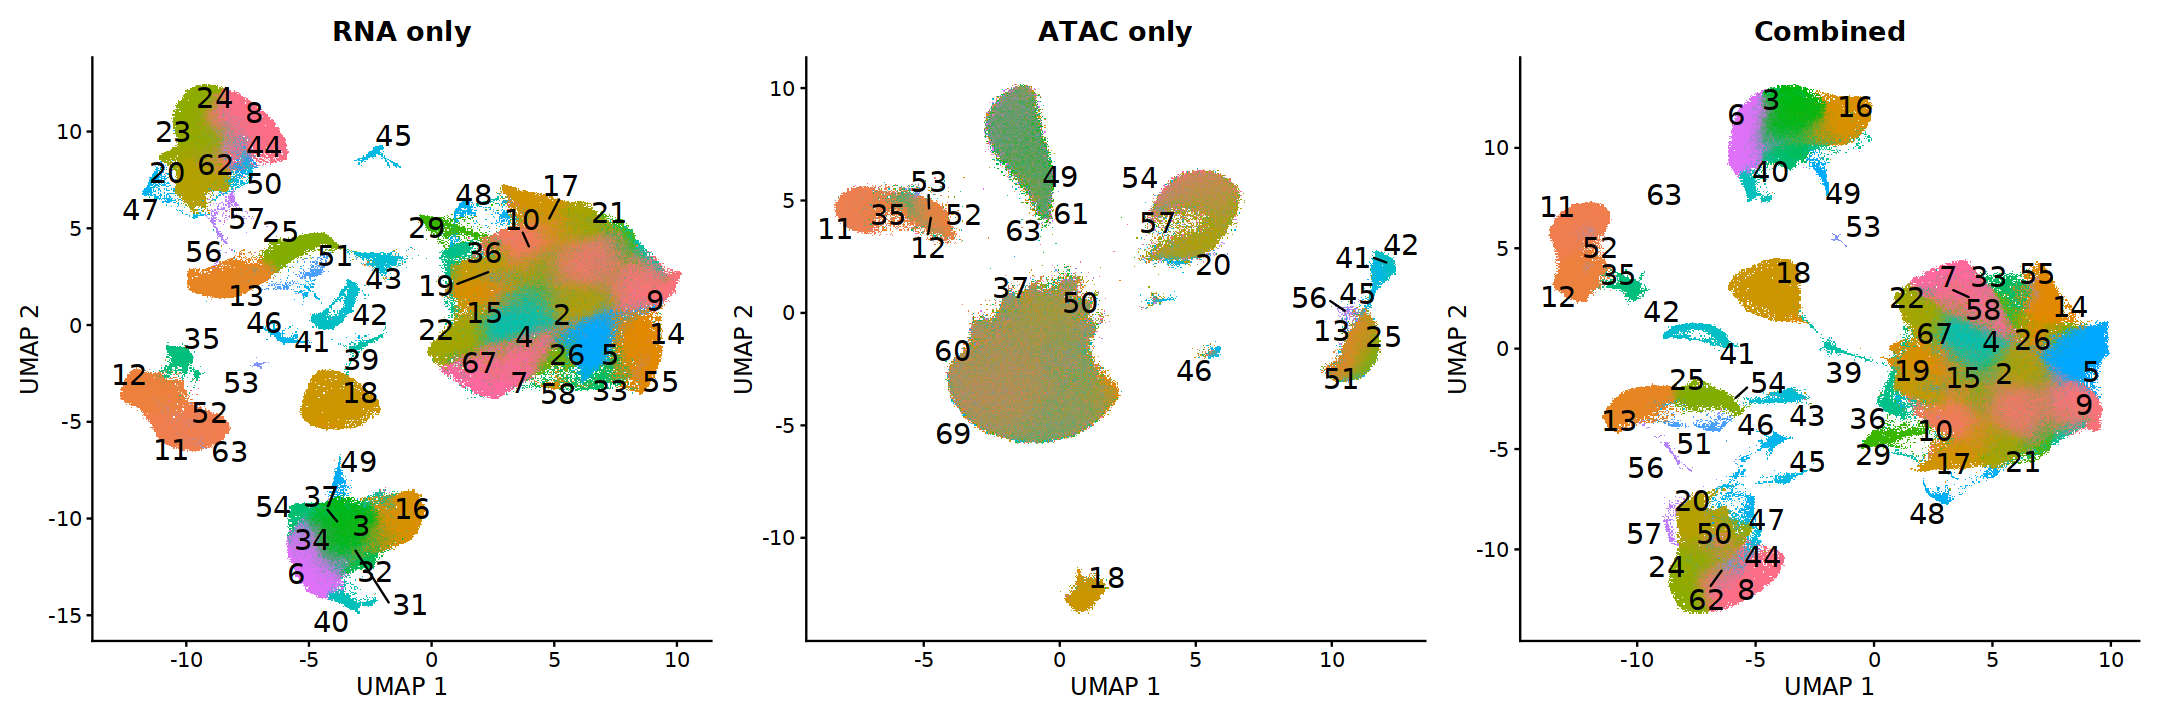

In [9]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='wnn_res2', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='wnn_res2', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='wnn_res2', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [10]:
saveRDS(adata, '/nfs/lab/projects/nash_nafld_liver/keep_demux/06052024_fnih_liver_ALL28lanes_ALL87donors_50kHVWsby16pool_HarmonyCovariates_DonorDemuxAndPoolingBatch_filtered_amulet_high_res_2.rds')


In [11]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,12534822,669.5,59241399,3163.9,74051748,3954.8
Vcells,1638550024,12501.2,4685927491,35750.8,10392679307,79289.9


In [12]:
#cell counts per cluster
table(adata$wnn_res2)


    1    10    11    12    13    14    15    16    17    18    19     2    20 
30379 16023 16016 13549 12083 11810 11549 11377 10871 10529 10211 22304  9665 
   21    22    23    24    25    26    27    28    29     3    30    31    32 
 9651  9432  8863  8182  7815  4720  4529  4313  3892 20413  3757  3556  3489 
   33    34    35    36    37    38    39     4    40    41    42    43    44 
 3240  3110  3106  3082  2835  2689  2211 20272  2199  1954  1936  1905  1893 
   45    46    47    48    49     5    50    51    52    53    54    55    56 
 1875  1739  1246  1205   934 17855   608   570   469   462   438   393   336 
   57    58    59     6    60    61    62    63    64    65    66    67    68 
  289     3     2 17251     2     2     2     2     2     2     2     2   935 
   69     7    70     8     9 
    2 17227     2 16236 16048 

In [19]:
adata_sub <- subset(adata, idents = as.character(1:57))
adata_sub

An object of class Seurat 
157583 features across 424591 samples within 4 assays 
Active assay: windows (50000 features, 50000 variable features)
 2 layers present: counts, data
 3 other assays present: RNA, RNA_raw, SCT
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [16]:
#This is the marker gene list that has 3 each and the additional cell types we discovered last time. 
# reLoad marker list that has additional cell types and compartment 
#CHANGE file name 
# paste means con
cell.markers = read.table("/nfs/lab/scorban/fnih_liver_231110/intregration/assests/Liver.Marker.Gene.List.3only_2.txt", sep = "\t", header = TRUE)
# Make it long, remove useless column and void markers
cell.markers <- cell.markers %>% gather(Key, marker, c(3:ncol(cell.markers)))
cell.markers = cell.markers[,-3]
cell.markers = cell.markers[cell.markers$marker != "", ]


# Factorize columns -- creating an order of the cells for the graphs 
cell.markers$Compartment = factor(cell.markers$Compartment, 
                        levels = c("Liver", "Immune", "Vascular", "Stromal", "Other"))
cell.markers$CellType = factor(cell.markers$CellType,
                        levels = c("Hepatoblasts", "Hepatocyte", "Cholangiocyte", "Hepatic_stellate_cell", "Kupffer_cell", 
                                   "Macrophage", "Myeloid", "B_cell", "Mast", "DC", "Plasma", "T_cell-NK", "T_cell", "NK", 
                                   "Endothelial", "Lymph-Endo", 
                                   "Fibroblast", "Adipocyte", "Myofibroblast", 
                                   "Erythrocytes"))

cell.compartment = cell.markers[,-3]

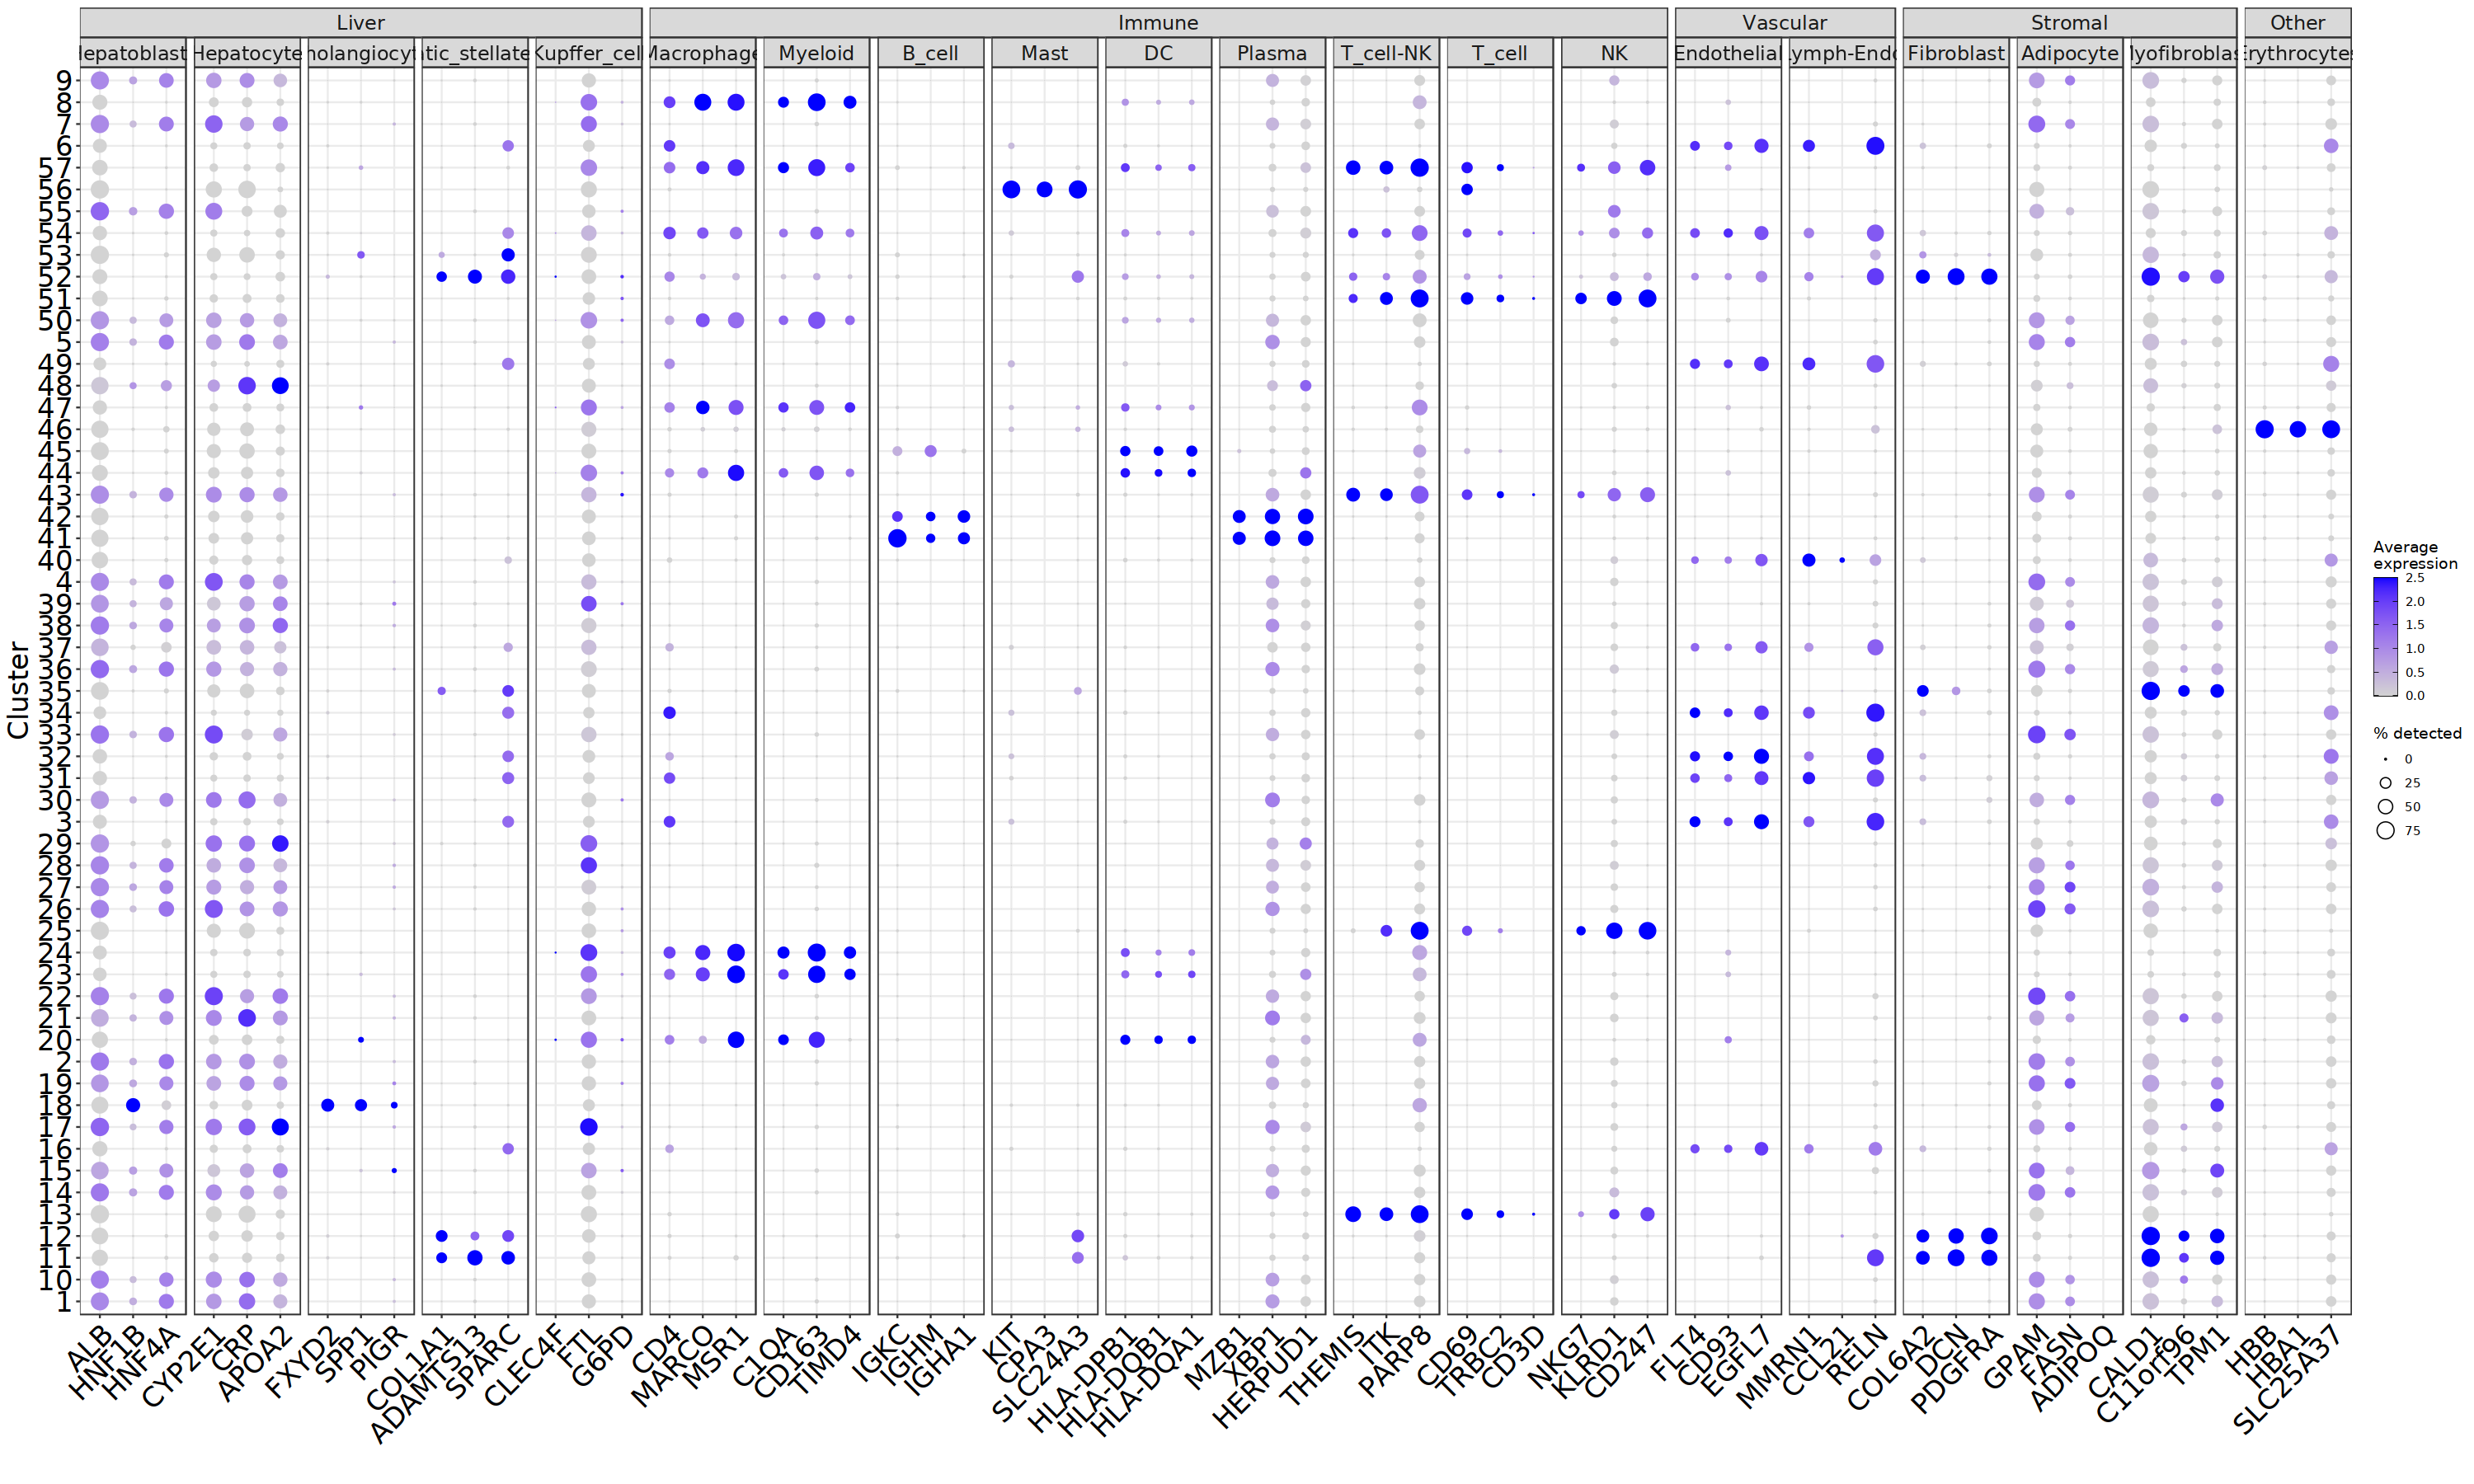

In [22]:
#reMaking a dot plot with cell type markers. We will use this to not only assign cell types, but also narrow down the markers, since I have too many liver marker genes.
#Change width and height, since I'll have so many markers to visualize. (previous width/height was 25/10).
g = DotPlot(adata_sub, assay='SCT', features=cell.markers$marker, group.by='wnn_res2', col.min=0) +
        theme(axis.text.x=element_text(angle=45, hjust=1)) + xlab('') + ylab('')
    meta_summary = g$data
    colnames(meta_summary)[3] = "marker"
    meta_summary = merge(meta_summary, cell.markers, by = "marker")

    options(repr.plot.width=25, repr.plot.height=15)
    figure <- ggplot(meta_summary, aes(x = marker, y = id)) +
      geom_point(aes(size = pct.exp, fill = avg.exp.scaled, stroke=NA),
                 shape = 21) +
      scale_size("% detected", range = c(0, 6)) +
      scale_fill_gradient(low = "lightgray", high = "blue",
                           guide = guide_colorbar(nbin = 200,
                                                  ticks.colour = "black", frame.colour = "black"),
                           name = "Average\nexpression") +
      ylab("Cluster") + xlab("") +
      theme_bw() +
      theme(axis.text = element_text(size = 100),
            axis.text.x = element_text(size = 20, angle = 45, hjust = 1, color = "black"),
            strip.text.x = element_text(size = 14),
            axis.text.y = element_text(size = 20, color = "black"),
            axis.title = element_text(size = 20)) +
      facet_nested(cols = vars(Compartment, CellType), scales = "free", space = "free")
figure

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



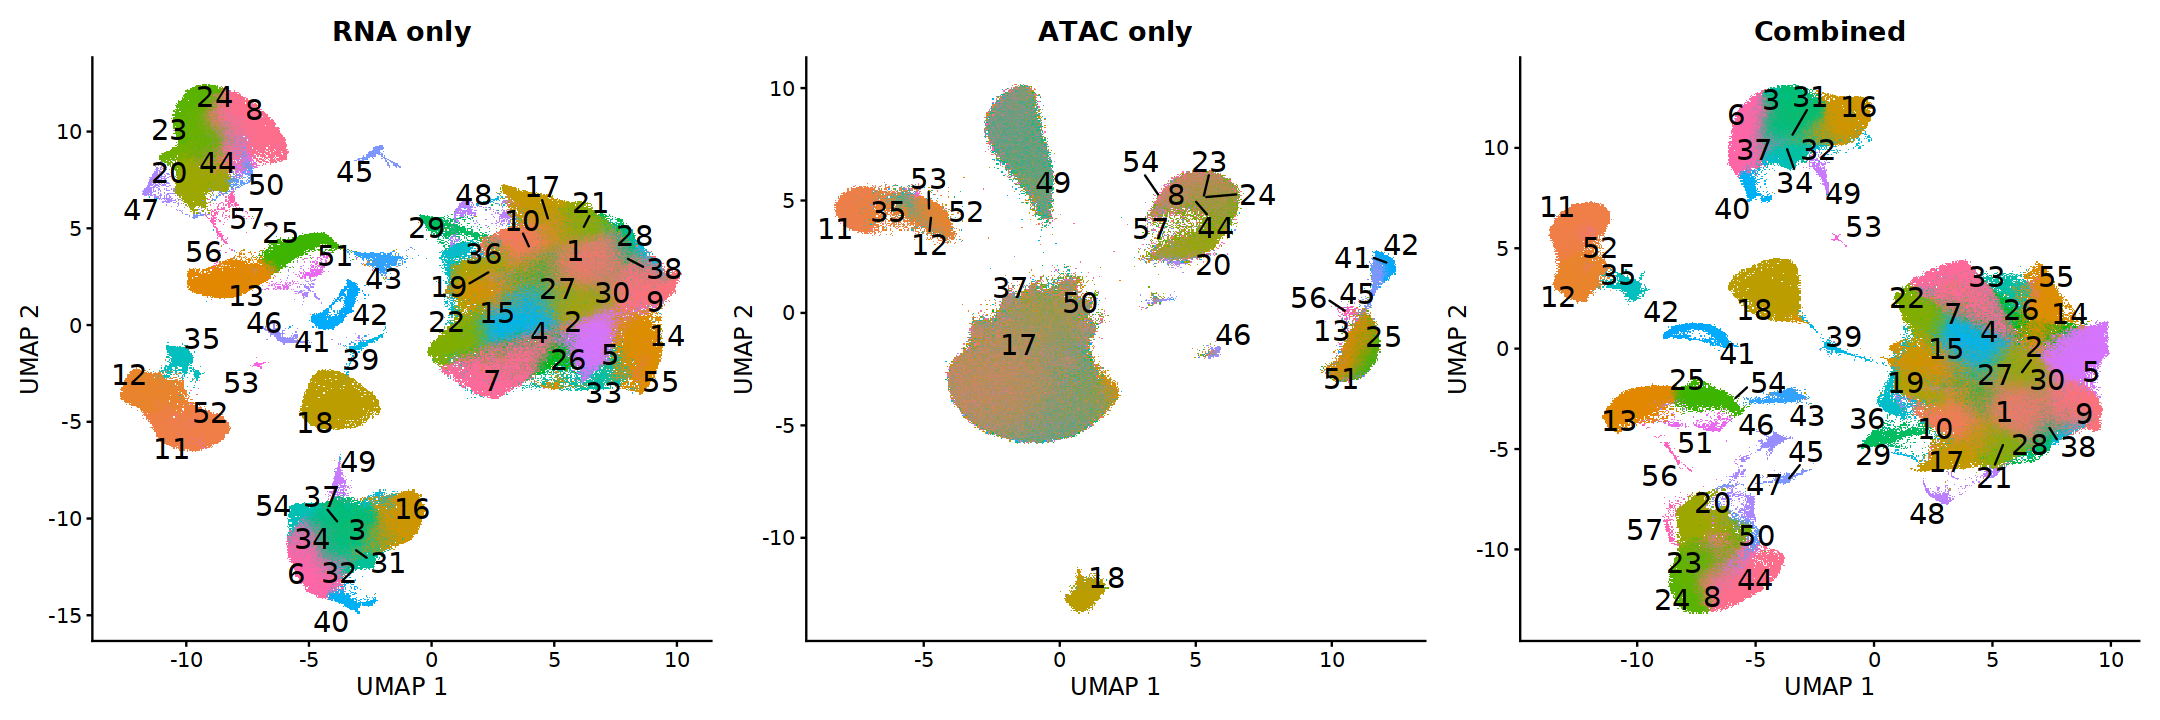

In [24]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata_sub, reduction='umap.rna', group.by='wnn_res2', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata_sub, reduction='umap.atac', group.by='wnn_res2', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata_sub, reduction='umap.wnn', group.by='wnn_res2', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



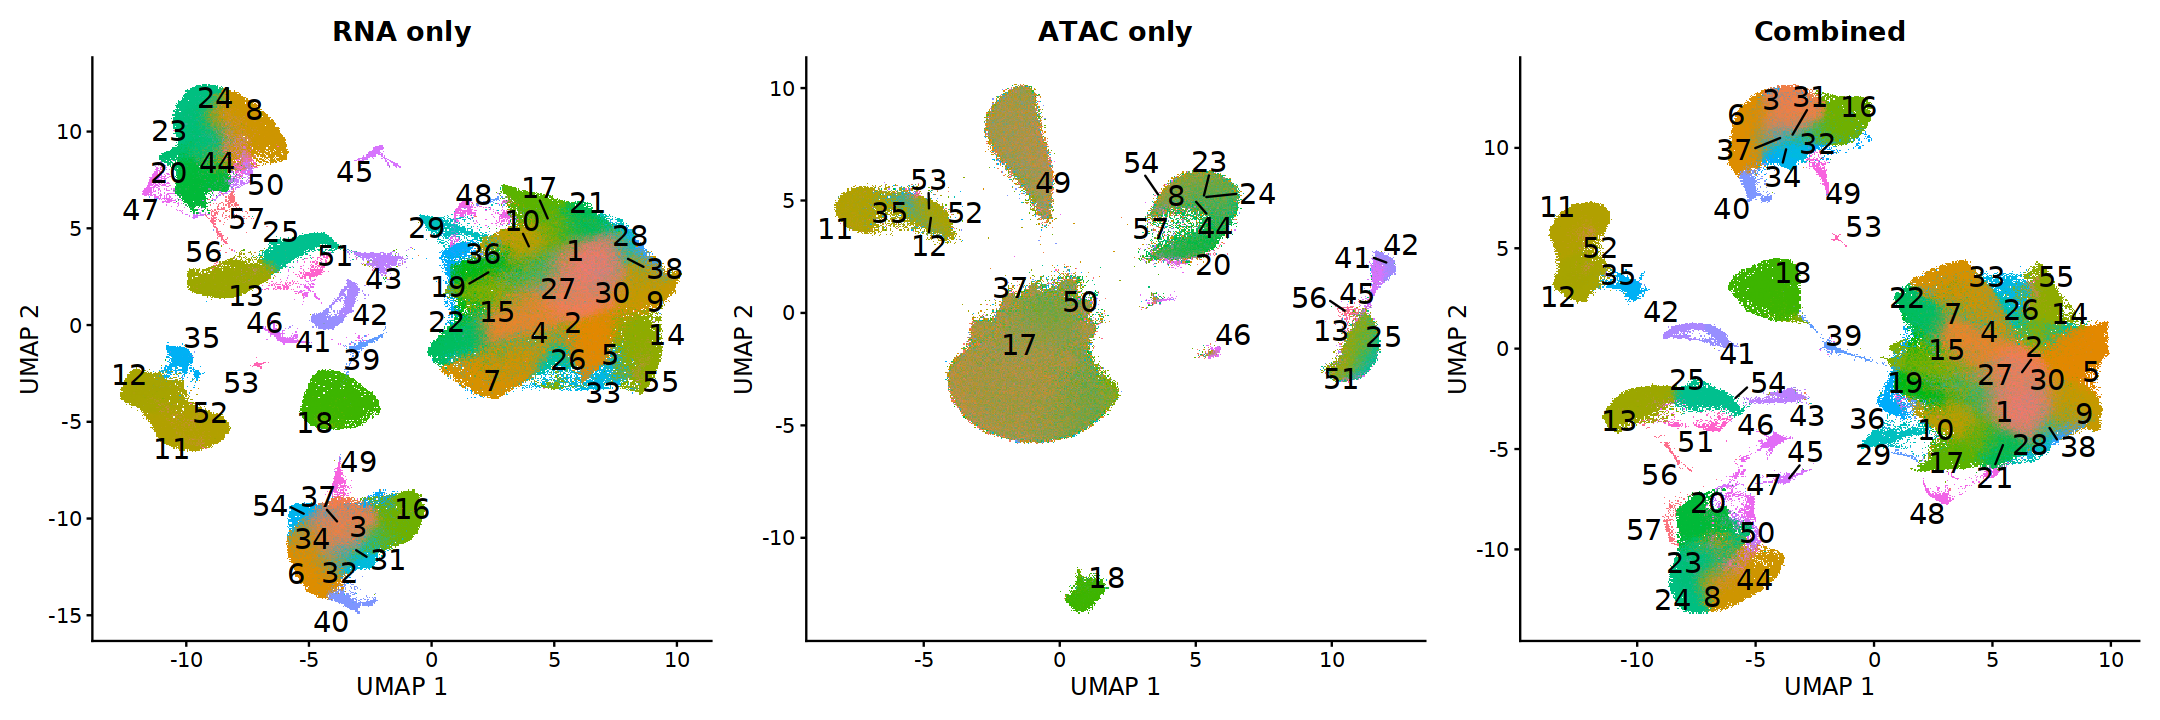

In [27]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata_sub, reduction='umap.rna', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata_sub, reduction='umap.atac', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata_sub, reduction='umap.wnn', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [29]:
unique(adata$seurat_clusters)

[1] 6  7  2  3  5  16 29 26 48 14 4  1  19 13 28 11 32 30 31 36 35 21 9  18 10
[26] 38 8  15 39 27 37 24 23 12 22 53 20 40 17 34 25 54 43 45 68 42 50 47 59 33
[51] 41 49 52 51 44 57 46 56 61 55 60 62 63 64 65 67 58 66 70 69
70 Levels: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 ... 70

In [30]:
unique(Idents(adata_sub))

[1] 6  7  2  3  5  16 29 26 48 14 4  1  19 13 28 11 32 30 31 36 35 21 9  18 10
[26] 38 8  15 39 27 37 24 23 12 22 53 20 40 17 34 25 54 43 45 42 50 47 33 41 49
[51] 52 51 44 57 46 56 55
57 Levels: 1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 ... 57

In [31]:
table(adata_sub[[]][c('wnn_res2','amulet')])

        amulet
wnn_res2 doublet singlet
      1      284   30095
      10     163   15860
      11     121   15895
      12     147   13402
      13      37   12046
      14     124   11686
      15     272   11277
      16      66   11311
      17     230   10641
      18     106   10423
      19     257    9954
      2      158   22146
      20      65    9600
      21     104    9547
      22     121    9311
      23      23    8840
      24      10    8172
      25      23    7792
      26      77    4643
      27      33    4496
      28      34    4279
      29      58    3834
      3      127   20286
      30      29    3728
      31      21    3535
      32      16    3473
      33      32    3208
      34      16    3094
      35      25    3081
      36      33    3049
      37     134    2701
      38      18    2671
      39     103    2108
      4      263   20009
      40      19    2180
      41     115    1839
      42     103    1833
      43     159    1746
      44  

In [32]:
table(adata_sub[[]][c('wnn_res2','amulet')])[,1] * 100 / table(adata_sub[[]][c('wnn_res2','amulet')])[,2]

1         10         11         12         13         14         15 
 0.9436784  1.0277427  0.7612457  1.0968512  0.3071559  1.0610988  2.4119890 
        16         17         18         19          2         20         21 
 0.5835028  2.1614510  1.0169817  2.5818766  0.7134471  0.6770833  1.0893474 
        22         23         24         25         26         27         28 
 1.2995382  0.2601810  0.1223691  0.2951745  1.6584105  0.7339858  0.7945782 
        29          3         30         31         32         33         34 
 1.5127804  0.6260475  0.7778970  0.5940594  0.4606968  0.9975062  0.5171299 
        35         36         37         38         39          4         40 
 0.8114249  1.0823221  4.9611255  0.6739049  4.8861480  1.3144085  0.8715596 
        41         42         43         44         45         46         47 
 6.2533986  5.6192035  9.1065292  1.2841091  1.2965964 10.9763880 11.5487914 
        48         49          5         50         51         52         53 
 1.3456686 13.3495146  1.2188209 13.2216015 11.3281250  9.3240093  0.4347826 
        54         55         56         57         58         59          6 
11.4503817  1.0282776  0.2985075 12.8906250        NaN        NaN  0.5654658 
        60         61         62         63         64         65         66 
       NaN        NaN        NaN        NaN        NaN        NaN        NaN 
        67         68         69          7         70          8          9 
       NaN        NaN        NaN  1.6522098        NaN  0.2655468  1.1279854

In [35]:
c('Hepatocyte','Hepatocyte','Endothelial','Hepatocyte','Hepatocyte',
'Endothelial','Hepatocyte','Macrophage','Hepatocyte','Hepatocyte',
'Stellate','Stellate','Immune','Hepatocyte','Hepatocyte',
'Endothelial','Hepatocyte','Cholangiocyte','Hepatocyte','Macrophage',
'Hepatocyte','Hepatocyte','Macrophage','Macrophage','Immune',
'Hepatocyte','Hepatocyte','Hepatocyte','Hepatocyte','Hepatocyte',
'Endothelial','Endothelial','Hepatocyte','Endothelial','Stellate',
'Hepatocyte','Endothelial','Hepatocyte','Hepatocyte','Endothelial',
'Immune','Immune','Immune','Macrophage','Macrophage',
'Eryhtoblast','Macrophage','Hepatocyte','Endothelial','Hepatocyte',
'Immune','Stellate','Schwann','Immune','Hepatocyte',
'Immune','Macrophage')

[1] "Hepatocyte"       "Endothelial"      "Macrophage"       "Hepatocyte"      
 [5] "Hepatocyte"       "Hepatocyte"       "Hepatocyte"       "Hepatocyte"      
 [9] "Hepatic_Stellate" "Hepatocyte"       "Hepatic_Stellate" "T_cells"         
[13] "DC"               "Cholangiocyte"    "Hepatocyte"       "NK"              
[17] "Hepatocyte"       "Hepatocyte"       "B_cells"          "Hepatocyte"      
[21] "Myofibroblasts"   "Endothelial"      "Endothelial"      "T_cells"         
[25] "DC"               "Erythrocytes"     "Mast"             "Hepatocyte"      
[29] "Uknown"           "Macrophage"

In [33]:
# list cluster numbers as they appear in the dotplot
clusters = 1:57

# visually determine celltypes
celltypes = c('Hepatocyte','Hepatocyte','Endothelial','Hepatocyte','Hepatocyte',
              'Endothelial','Hepatocyte','Macrophage','Hepatocyte','Hepatocyte',
              'Stellate','Stellate','Immune','Hepatocyte','Hepatocyte',
              'Endothelial','Hepatocyte','Cholangiocyte','Hepatocyte','Macrophage',
              'Hepatocyte','Hepatocyte','Macrophage','Macrophage','Immune',
              'Hepatocyte','Hepatocyte','Hepatocyte','Hepatocyte','Hepatocyte',
              'Endothelial','Endothelial','Hepatocyte','Endothelial','Stellate',
              'Hepatocyte','Endothelial','Hepatocyte','Hepatocyte','Endothelial',
              'Immune','Immune','Immune','Macrophage','Macrophage',
              'Eryhtoblast','Macrophage','Hepatocyte','Endothelial','Hepatocyte',
              'Immune','Stellate','Schwann','Immune','Hepatocyte',
              'Immune','Macrophage')

length(clusters)
length(celltypes)

clusters.celltypes = data.frame(seurat_clusters = clusters,
                               celltypes = celltypes)

[1] 57

[1] 57

In [34]:
adata_sub <- SetIdent(adata_sub, value = adata_sub$seurat_clusters)
levels(adata_sub)
adata_sub$celltypes <- clusters.celltypes$celltypes[match(adata_sub$seurat_clusters, clusters.celltypes$seurat_clusters)]
adata_sub <- SetIdent(adata_sub, value = adata_sub$celltypes)
levels(adata_sub)

[1] "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "14" "15"
[16] "16" "17" "18" "19" "20" "21" "22" "23" "24" "25" "26" "27" "28" "29" "30"
[31] "31" "32" "33" "34" "35" "36" "37" "38" "39" "40" "41" "42" "43" "44" "45"
[46] "46" "47" "48" "49" "50" "51" "52" "53" "54" "55" "56" "57"

[1] "Endothelial"   "Hepatocyte"    "Immune"        "Stellate"     
[5] "Cholangiocyte" "Macrophage"    "Schwann"       "Eryhtoblast"

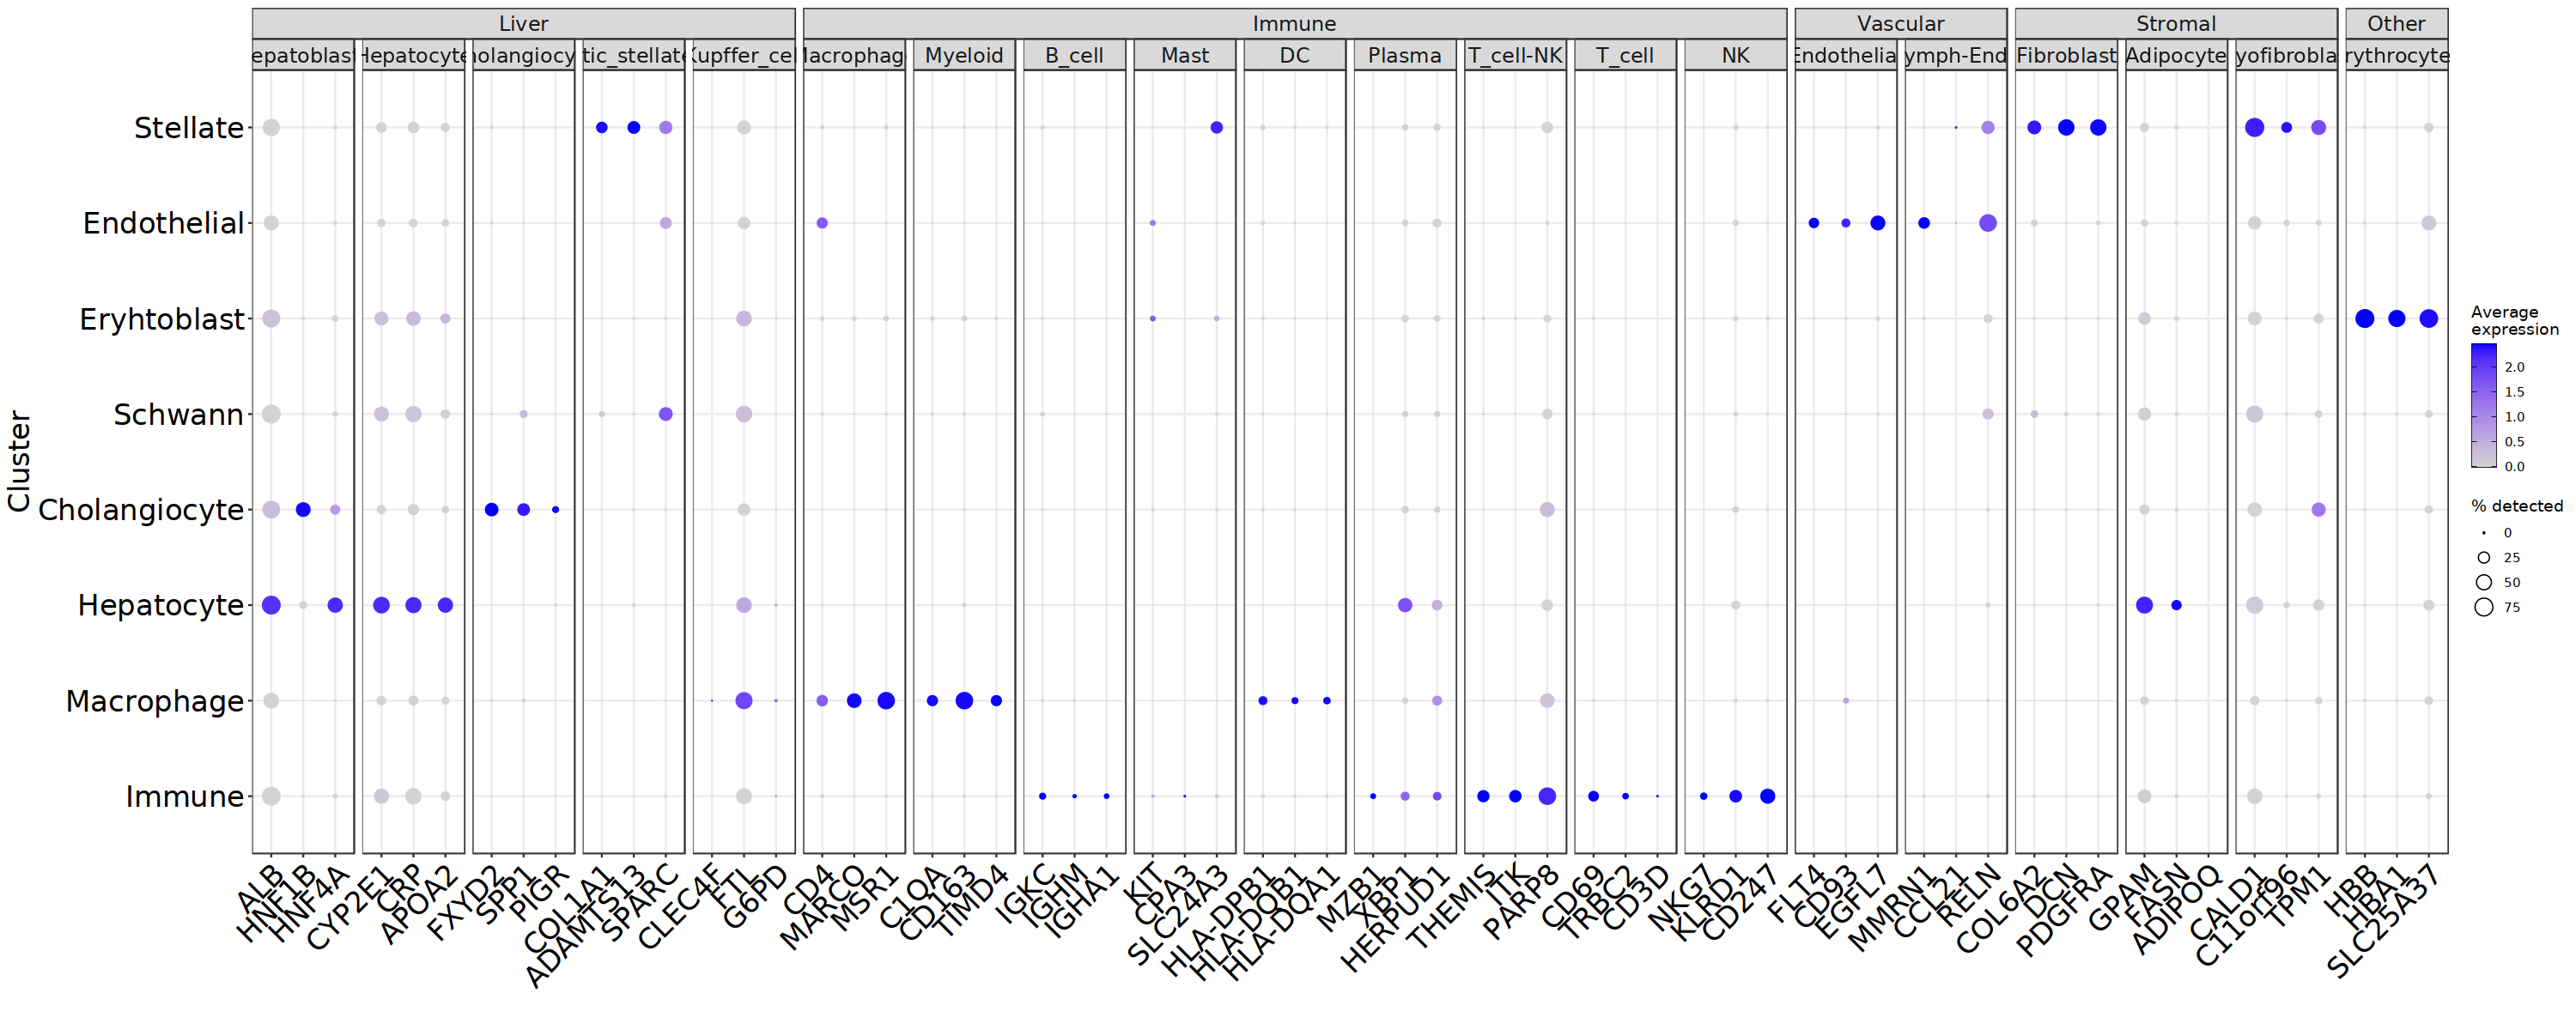

In [35]:
#reMaking a dot plot with cell type markers. We will use this to not only assign cell types, but also narrow down the markers, since I have too many liver marker genes.
#Change width and height, since I'll have so many markers to visualize. (previous width/height was 25/10).
g = DotPlot(adata_sub, assay='SCT', features=cell.markers$marker, cluster.idents=TRUE, col.min=0) +
        theme(axis.text.x=element_text(angle=45, hjust=1)) + xlab('') + ylab('')
    meta_summary = g$data
    colnames(meta_summary)[3] = "marker"
    meta_summary = merge(meta_summary, cell.markers, by = "marker")

    options(repr.plot.width=25, repr.plot.height=10)
    figure <- ggplot(meta_summary, aes(x = marker, y = id)) +
      geom_point(aes(size = pct.exp, fill = avg.exp.scaled, stroke=NA),
                 shape = 21) +
      scale_size("% detected", range = c(0, 6)) +
      scale_fill_gradient(low = "lightgray", high = "blue",
                           guide = guide_colorbar(nbin = 200,
                                                  ticks.colour = "black", frame.colour = "black"),
                           name = "Average\nexpression") +
      ylab("Cluster") + xlab("") +
      theme_bw() +
      theme(axis.text = element_text(size = 100),
            axis.text.x = element_text(size = 20, angle = 45, hjust = 1, color = "black"),
            strip.text.x = element_text(size = 14),
            axis.text.y = element_text(size = 20, color = "black"),
            axis.title = element_text(size = 20)) +
      facet_nested(cols = vars(Compartment, CellType), scales = "free", space = "free")
figure

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



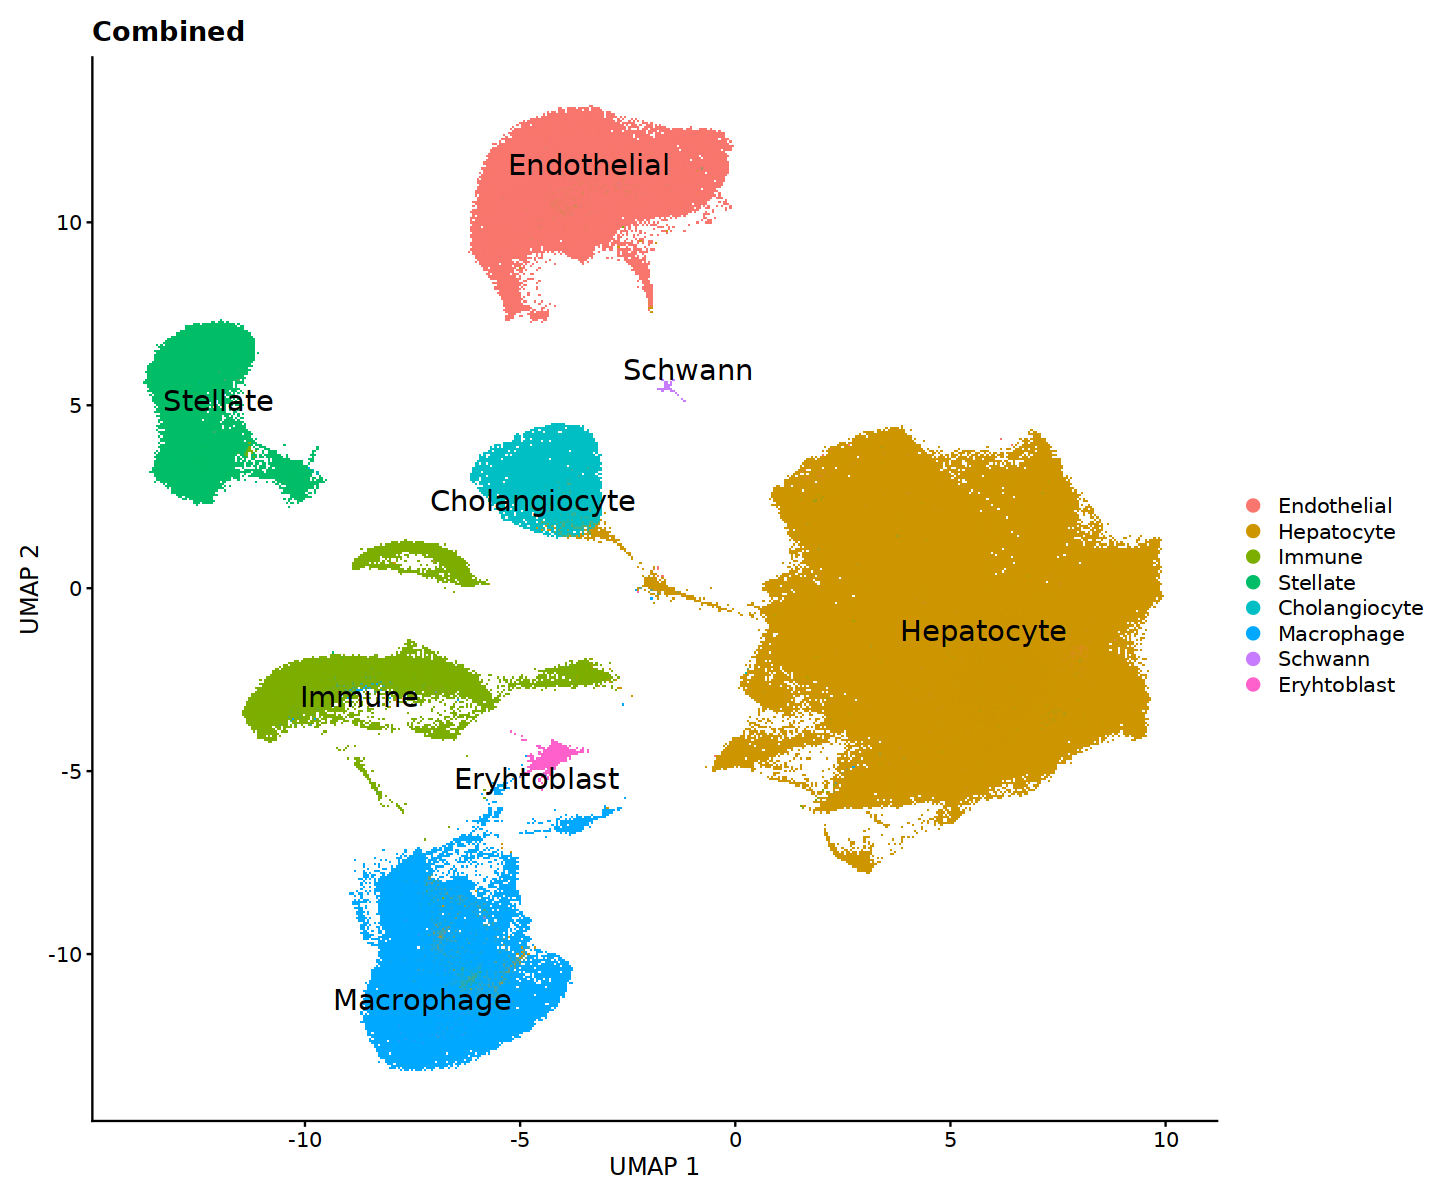

In [36]:
options(repr.plot.width=12, repr.plot.height=10)
DimPlot(adata_sub, reduction='umap.wnn', label=TRUE, label.size=6, repel=TRUE) +
ggtitle('WNN') + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



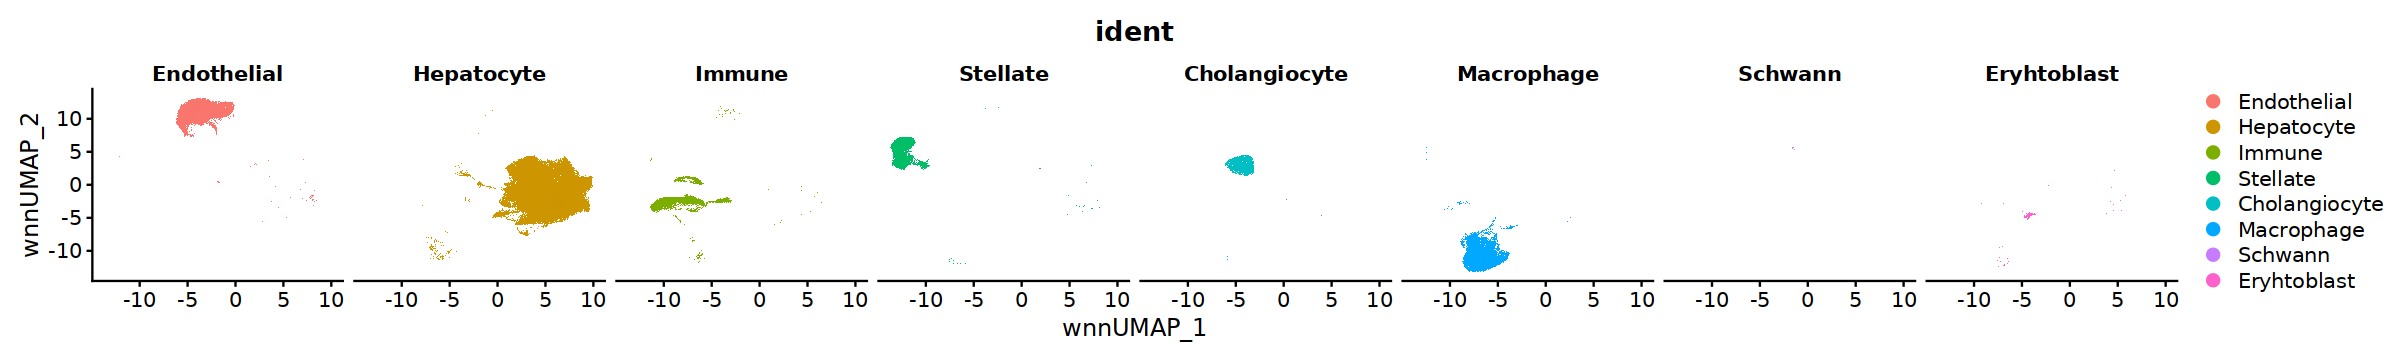

In [37]:
options(repr.plot.width=20, repr.plot.height=3)
p1 <- DimPlot(adata_sub, reduction='umap.wnn', group.by='ident', split.by='ident', label=FALSE, label.size=20, repel=TRUE)
p1

In [38]:
table(Idents(adata_sub))


  Endothelial    Hepatocyte        Immune      Stellate Cholangiocyte 
        65164        238271         27037         33140         10529 
   Macrophage       Schwann   Eryhtoblast 
        48249           462          1739 

In [39]:
table(adata_sub[[]][c('seurat_clusters','amulet')])

               amulet
seurat_clusters doublet singlet
             1      284   30095
             2      158   22146
             3      127   20286
             4      263   20009
             5      215   17640
             6       97   17154
             7      280   16947
             8       43   16193
             9      179   15869
             10     163   15860
             11     121   15895
             12     147   13402
             13      37   12046
             14     124   11686
             15     272   11277
             16      66   11311
             17     230   10641
             18     106   10423
             19     257    9954
             20      65    9600
             21     104    9547
             22     121    9311
             23      23    8840
             24      10    8172
             25      23    7792
             26      77    4643
             27      33    4496
             28      34    4279
             29      58    3834
             30   

In [40]:
table(adata_sub[[]][c('seurat_clusters','amulet')])[,1] * 100 / table(adata_sub[[]][c('seurat_clusters','amulet')])[,2]

1          2          3          4          5          6          7 
 0.9436784  0.7134471  0.6260475  1.3144085  1.2188209  0.5654658  1.6522098 
         8          9         10         11         12         13         14 
 0.2655468  1.1279854  1.0277427  0.7612457  1.0968512  0.3071559  1.0610988 
        15         16         17         18         19         20         21 
 2.4119890  0.5835028  2.1614510  1.0169817  2.5818766  0.6770833  1.0893474 
        22         23         24         25         26         27         28 
 1.2995382  0.2601810  0.1223691  0.2951745  1.6584105  0.7339858  0.7945782 
        29         30         31         32         33         34         35 
 1.5127804  0.7778970  0.5940594  0.4606968  0.9975062  0.5171299  0.8114249 
        36         37         38         39         40         41         42 
 1.0823221  4.9611255  0.6739049  4.8861480  0.8715596  6.2533986  5.6192035 
        43         44         45         46         47         48         49 
 9.1065292  1.2841091  1.2965964 10.9763880 11.5487914  1.3456686 13.3495146 
        50         51         52         53         54         55         56 
13.2216015 11.3281250  9.3240093  0.4347826 11.4503817  1.0282776  0.2985075 
        57         58         59         60         61         62         63 
12.8906250        NaN        NaN        NaN        NaN        NaN        NaN 
        64         65         66         67         68         69         70 
       NaN        NaN        NaN        NaN        NaN        NaN        NaN

In [41]:
adata_sub$ct <- Idents(adata_sub)

In [42]:
table(adata_sub[[]][c('ct','amulet')])[,1] * 100 / table(adata_sub[[]][c('ct','amulet')])[,2]

Endothelial    Hepatocyte        Immune      Stellate Cholangiocyte 
    0.9386908     1.3431839     2.0418176     1.0150273     1.0169817 
   Macrophage       Schwann   Eryhtoblast 
    0.7328072     0.4347826    10.9763880

In [209]:
saveRDS(adata, '/nfs/lab/projects/nash_nafld_liver/keep_demux/06052024_fnih_liver_ALL28lanes_ALL87donors_50kHVWsby16pool_HarmonyCovariates_DonorDemuxAndPoolingBatch_filtered_amulet_high_res_2_ct.rds')

In [ ]:
adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 10, verbose=TRUE, method = 'igraph', cluster.name = 'wnn_res10')

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
saveRDS(adata, '/nfs/lab/projects/nash_nafld_liver/keep_demux/06052024_fnih_liver_ALL28lanes_ALL87donors_50kHVWsby16pool_HarmonyCovariates_DonorDemuxAndPoolingBatch_filtered_amulet_high_res_10.rds')


In [ ]:
gc()

In [ ]:
#cell counts per cluster
table(adata$wnn_res10)

In [ ]:
table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]

In [ ]:
which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 2)

In [ ]:
ggplot(data.frame(amulet.pct=table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]),
       aes(x=amulet.pct)) + geom_histogram(bins=200) + xlim(0,10)

In [ ]:
(table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2])[which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 5)]

In [ ]:
unique(Idents(adata))[!unique(Idents(adata)) %in% names(which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 2))]

In [ ]:
adata_sub <- subset(adata, idents = as.character(unique(Idents(adata))[!unique(Idents(adata)) %in% names(which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 2))]))
adata
adata_sub

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata_sub, reduction='umap.rna', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata_sub, reduction='umap.atac', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata_sub, reduction='umap.wnn', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
#This is the marker gene list that has 3 each and the additional cell types we discovered last time. 
# reLoad marker list that has additional cell types and compartment 
#CHANGE file name 
# paste means con
cell.markers = read.table("/nfs/lab/scorban/fnih_liver_231110/intregration/assests/Liver.Marker.Gene.List.3only_2.txt", sep = "\t", header = TRUE)
# Make it long, remove useless column and void markers
cell.markers <- cell.markers %>% gather(Key, marker, c(3:ncol(cell.markers)))
cell.markers = cell.markers[,-3]
cell.markers = cell.markers[cell.markers$marker != "", ]


# Factorize columns -- creating an order of the cells for the graphs 
cell.markers$Compartment = factor(cell.markers$Compartment, 
                        levels = c("Liver", "Immune", "Vascular", "Stromal", "Other"))
cell.markers$CellType = factor(cell.markers$CellType,
                        levels = c("Hepatoblasts", "Hepatocyte", "Cholangiocyte", "Hepatic_stellate_cell", "Kupffer_cell", 
                                   "Macrophage", "Myeloid", "B_cell", "Mast", "DC", "Plasma", "T_cell-NK", "T_cell", "NK", 
                                   "Endothelial", "Lymph-Endo", 
                                   "Fibroblast", "Adipocyte", "Myofibroblast", 
                                   "Erythrocytes"))

cell.compartment = cell.markers[,-3]

In [ ]:
#reMaking a dot plot with cell type markers. We will use this to not only assign cell types, but also narrow down the markers, since I have too many liver marker genes.
#Change width and height, since I'll have so many markers to visualize. (previous width/height was 25/10).
g = DotPlot(adata_cluster, assay='SCT', features=cell.markers$marker, group.by='wnn_res10', col.min=0) +
        theme(axis.text.x=element_text(angle=45, hjust=1)) + xlab('') + ylab('')
    meta_summary = g$data
    colnames(meta_summary)[3] = "marker"
    meta_summary = merge(meta_summary, cell.markers, by = "marker")

    options(repr.plot.width=20, repr.plot.height=10)
    figure <- ggplot(meta_summary, aes(x = marker, y = id)) +
      geom_point(aes(size = pct.exp, fill = avg.exp.scaled, stroke=NA),
                 shape = 21) +
      scale_size("% detected", range = c(0, 6)) +
      scale_fill_gradient(low = "lightgray", high = "blue",
                           guide = guide_colorbar(nbin = 200,
                                                  ticks.colour = "black", frame.colour = "black"),
                           name = "Average\nexpression") +
      ylab("Cluster") + xlab("") +
      theme_bw() +
      theme(axis.text = element_text(size = 100),
            axis.text.x = element_text(size = 20, angle = 45, hjust = 1, color = "black"),
            strip.text.x = element_text(size = 14),
            axis.text.y = element_text(size = 20, color = "black"),
            axis.title = element_text(size = 20)) +
      facet_nested(cols = vars(Compartment, CellType), scales = "free", space = "free")
figure

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=90, repr.plot.height=30)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
DefaultAssay(adata) <- 'SCT'

In [ ]:
options(repr.plot.width=30, repr.plot.height=30)
FeaturePlot(object=adata, reduction='umap.wnn', features = 'SLC25A37', order = T)

In [ ]:
options(repr.plot.width=30, repr.plot.height=30)
FeaturePlot(object=adata, reduction='umap.wnn', features = 'SLC25A37', order = F)

In [ ]:
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='amulet', label=TRUE, label.size=6, repel=TRUE, alpha=0.25) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p3

In [ ]:
adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 15, verbose=TRUE, method = 'igraph', cluster.name = 'wnn_res10')

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
saveRDS(adata, '/nfs/lab/projects/nash_nafld_liver/keep_demux/06052024_fnih_liver_ALL28lanes_ALL87donors_50kHVWsby16pool_HarmonyCovariates_DonorDemuxAndPoolingBatch_filtered_amulet_high_res_25.rds')


In [ ]:
gc()

In [ ]:
#cell counts per cluster
table(adata$wnn_res10)

In [ ]:
table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]

In [ ]:
which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 2)

In [ ]:
ggplot(data.frame(amulet.pct=table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]),
       aes(x=amulet.pct)) + geom_histogram(bins=200) + xlim(0,10)

In [ ]:
(table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2])[which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 5)]

In [ ]:
unique(Idents(adata))[!unique(Idents(adata)) %in% names(which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 2))]

In [ ]:
adata_sub <- subset(adata, idents = as.character(unique(Idents(adata))[!unique(Idents(adata)) %in% names(which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 2))]))
adata
adata_sub

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata_sub, reduction='umap.rna', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata_sub, reduction='umap.atac', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata_sub, reduction='umap.wnn', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 20, verbose=TRUE, method = 'igraph', cluster.name = 'wnn_res20')

In [ ]:
adata$wnn_res15 <- adata$wnn_res10

In [ ]:
adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 10, verbose=TRUE, method = 'igraph', cluster.name = 'wnn_res10')

In [ ]:
Idents(adata) <- adata$wnn_res20

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=18, repr.plot.height=6)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='wnn_res20', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='wnn_res20', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='wnn_res20', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
saveRDS(adata, '/nfs/lab/projects/nash_nafld_liver/keep_demux/06052024_fnih_liver_ALL28lanes_ALL87donors_50kHVWsby16pool_HarmonyCovariates_DonorDemuxAndPoolingBatch_filtered_amulet_high_res_20.rds')


In [ ]:
gc()

In [ ]:
#cell counts per cluster
table(adata$wnn_res20)

In [ ]:
table(adata[[]][c('wnn_res20','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res20','amulet')])[,2]

In [ ]:
which((table(adata[[]][c('wnn_res20','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res20','amulet')])[,2]) > 2)

In [ ]:
ggplot(data.frame(amulet.pct=table(adata[[]][c('wnn_res20','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res20','amulet')])[,2]),
       aes(x=amulet.pct)) + geom_histogram(bins=200) + xlim(0,10)

In [ ]:
(table(adata[[]][c('wnn_res20','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res20','amulet')])[,2])[which((table(adata[[]][c('wnn_res20','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res20','amulet')])[,2]) > 5)]

In [ ]:
unique(Idents(adata))[!unique(Idents(adata)) %in% names(which((table(adata[[]][c('wnn_res20','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res20','amulet')])[,2]) > 2))]

In [ ]:
Idents(adata) <- adata$wnn_res10
adata_sub <- subset(adata, idents = as.character(unique(Idents(adata))[!unique(Idents(adata)) %in% names(which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 5))]))
adata
adata_sub

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=90, repr.plot.height=30)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=90, repr.plot.height=30)
p1 <- DimPlot(adata_sub, reduction='umap.rna', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata_sub, reduction='umap.atac', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata_sub, reduction='umap.wnn', group.by='wnn_res10', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
(table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2])[which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 5)]

In [ ]:
Idents(adata) <- adata$wnn_res15
adata_sub <- subset(adata, idents = as.character(unique(Idents(adata))[!unique(Idents(adata)) %in% names(which((table(adata[[]][c('wnn_res15','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res15','amulet')])[,2]) > 5))]))
adata
adata_sub

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=90, repr.plot.height=30)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='wnn_res15', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='wnn_res15', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='wnn_res15', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=90, repr.plot.height=30)
p1 <- DimPlot(adata_sub, reduction='umap.rna', group.by='wnn_res15', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata_sub, reduction='umap.atac', group.by='wnn_res15', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata_sub, reduction='umap.wnn', group.by='wnn_res15', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
(table(adata[[]][c('wnn_res15','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res15','amulet')])[,2])[which((table(adata[[]][c('wnn_res15','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res15','amulet')])[,2]) > 5)]

In [ ]:
Idents(adata) <- adata$wnn_res20
adata_sub <- subset(adata, idents = as.character(unique(Idents(adata))[!unique(Idents(adata)) %in% names(which((table(adata[[]][c('wnn_res20','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res20','amulet')])[,2]) > 5))]))
adata
adata_sub

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=90, repr.plot.height=30)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='wnn_res20', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='wnn_res20', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='wnn_res20', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=90, repr.plot.height=30)
p1 <- DimPlot(adata_sub, reduction='umap.rna', group.by='wnn_res20', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata_sub, reduction='umap.atac', group.by='wnn_res20', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata_sub, reduction='umap.wnn', group.by='wnn_res20', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
(table(adata[[]][c('wnn_res20','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res20','amulet')])[,2])[which((table(adata[[]][c('wnn_res20','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res20','amulet')])[,2]) > 5)]

In [ ]:
gc()

In [ ]:
Idents(adata) <- adata$wnn_res2
adata_sub <- subset(adata, idents = as.character(unique(Idents(adata))[!unique(Idents(adata)) %in% names(which((table(adata[[]][c('wnn_res2','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res2','amulet')])[,2]) > 5))]))
adata
adata_sub

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=90, repr.plot.height=30)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='wnn_res2', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='wnn_res2', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='wnn_res2', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=90, repr.plot.height=30)
p1 <- DimPlot(adata_sub, reduction='umap.rna', group.by='wnn_res2', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata_sub, reduction='umap.atac', group.by='wnn_res2', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata_sub, reduction='umap.wnn', group.by='wnn_res2', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
(table(adata[[]][c('wnn_res2','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res2','amulet')])[,2])[which((table(adata[[]][c('wnn_res2','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res2','amulet')])[,2]) > 5)]

In [ ]:
adata <- FindClusters(adata, graph.name='wsnn', algorithm=4,  resolution = 5, verbose=TRUE, method = 'igraph', cluster.name = 'wnn_res5')

In [ ]:
Idents(adata) <- adata$wnn_res5
adata_sub <- subset(adata, idents = as.character(unique(Idents(adata))[!unique(Idents(adata)) %in% names(which((table(adata[[]][c('wnn_res5','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res5','amulet')])[,2]) > 5))]))
adata
adata_sub

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=90, repr.plot.height=30)
p1 <- DimPlot(adata, reduction='umap.rna', group.by='wnn_res5', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata, reduction='umap.atac', group.by='wnn_res5', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata, reduction='umap.wnn', group.by='wnn_res5', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
#CHANGE NOTHING
#Making UMAPs that are colored by cluster, will need to assign cell types later. 
options(repr.plot.width=90, repr.plot.height=30)
p1 <- DimPlot(adata_sub, reduction='umap.rna', group.by='wnn_res5', label=TRUE, label.size=6, repel=TRUE) + ggtitle('RNA')
p1 <- p1 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('RNA only')
p2 <- DimPlot(adata_sub, reduction='umap.atac', group.by='wnn_res5', label=TRUE, label.size=6, repel=TRUE) + ggtitle('ATAC')
p2 <- p2 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('ATAC only')
p3 <- DimPlot(adata_sub, reduction='umap.wnn', group.by='wnn_res5', label=TRUE, label.size=6, repel=TRUE) + ggtitle('WNN')
p3 <- p3 + xlab('UMAP 1') + ylab('UMAP 2') + ggtitle('Combined')
p1 + p2 + p3 & NoLegend() & theme(plot.title=element_text(hjust=0.5))

In [ ]:
(table(adata[[]][c('wnn_res5','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res5','amulet')])[,2])[which((table(adata[[]][c('wnn_res5','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res5','amulet')])[,2]) > 5)]

In [ ]:
saveRDS(adata, '/nfs/lab/projects/nash_nafld_liver/keep_demux/06052024_fnih_liver_ALL28lanes_ALL87donors_50kHVWsby16pool_HarmonyCovariates_DonorDemuxAndPoolingBatch_filtered_amulet_high_res_all.rds')


In [ ]:
gc()

In [ ]:
adata_sub <- NULL
adata_cluster <- NULL
adata_cluster_sub <- NULL
gc()

In [ ]:
Idents(adata) <- adata$wnn_res10
adata <- subset(adata, idents = as.character(unique(Idents(adata))[!unique(Idents(adata)) %in% names(which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 5))]))
adata

gc()

In [491]:
saveRDS(adata, '/nfs/lab/projects/nash_nafld_liver/keep_demux/06052024_fnih_liver_ALL28lanes_ALL87donors_50kHVWsby16pool_HarmonyCovariates_DonorDemuxAndPoolingBatch_filtered_amulet_res10_5pctamulet_subset.rds')

# July 8  

How many of those cells came from hepatocytes?

In [5]:
adata <- readRDS('/nfs/lab/projects/nash_nafld_liver/keep_demux/06052024_fnih_liver_ALL28lanes_ALL87donors_50kHVWsby16pool_HarmonyCovariates_DonorDemuxAndPoolingBatch_filtered_amulet_high_res_all.rds')
adata

An object of class Seurat 
157583 features across 425551 samples within 4 assays 
Active assay: SCT (34381 features, 3000 variable features)
 3 layers present: data, counts, scale.data
 3 other assays present: RNA, RNA_raw, windows
 7 dimensional reductions calculated: pca, harmony.rna, umap.rna, lsi, harmony.atac, umap.atac, umap.wnn

In [25]:
adata$keep_bc <- TRUE
adata[[]][adata$wnn_res10 %in% names(which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 5)),]$keep_bc <- FALSE


In [28]:
adata$no_keep_bc <- FALSE
adata[[]][adata$wnn_res10 %in% names(which((table(adata[[]][c('wnn_res10','amulet')])[,1] * 100 / table(adata[[]][c('wnn_res10','amulet')])[,2]) > 5)),]$keep_bc <- TRUE


In [16]:
colnames(adata[[]])

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "nCount_ATAC"                       "nFeature_ATAC"                    
 [9] "donor_demux"                       "nCount_SCT"                       
[11] "nFeature_SCT"                      "SCT.weight"                       
[13] "ATAC.weight"                       "wsnn_res.0.2"                     
[15] "seurat_clusters"                   "log_nCount_ATAC"                  
[17] "log_nCount_SCT"                    "log_nFeature_ATAC"                
[19] "log_nFeature_SCT"                  "lane"                             
[21] "batch"                             "nCount_windows"                   
[23] "nFeature_windows"                  "gex_raw_reads"                    
[25] "gex_mapped_reads"                  "gex_conf_intergenic_reads"        
[27] "gex_conf_exonic_reads"             "gex_conf_intronic_reads"          
[29] "gex_conf_exonic_unique_reads"      "gex_conf_exonic_antisense_reads"  
[31] "gex_conf_exonic_dup_reads"         "gex_exonic_umis"                  
[33] "gex_conf_intronic_unique_reads"    "gex_conf_intronic_antisense_reads"
[35] "gex_conf_intronic_dup_reads"       "gex_intronic_umis"                
[37] "gex_conf_txomic_unique_reads"      "gex_umis_count"                   
[39] "gex_genes_count"                   "atac_raw_reads"                   
[41] "atac_unmapped_reads"               "atac_lowmapq"                     
[43] "atac_dup_reads"                    "atac_chimeric_reads"              
[45] "atac_mitochondrial_reads"          "atac_fragments"                   
[47] "atac_TSS_fragments"                "atac_peak_region_fragments"       
[49] "atac_peak_region_cutsites"         "TSS.enrichment"                   
[51] "TSS.percentile"                    "condition"                        
[53] "disease_status"                    "library"                          
[55] "windows.weight"                    "wsnn_res.0.25"                    
[57] "amulet"                            "wsnn_res.0.5"                     
[59] "wnn_res1"                          "wnn_res2"                         
[61] "wnn_res10"                         "wnn_res20"                        
[63] "wnn_res15"                         "wnn_res5"                         
[65] "keep"

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



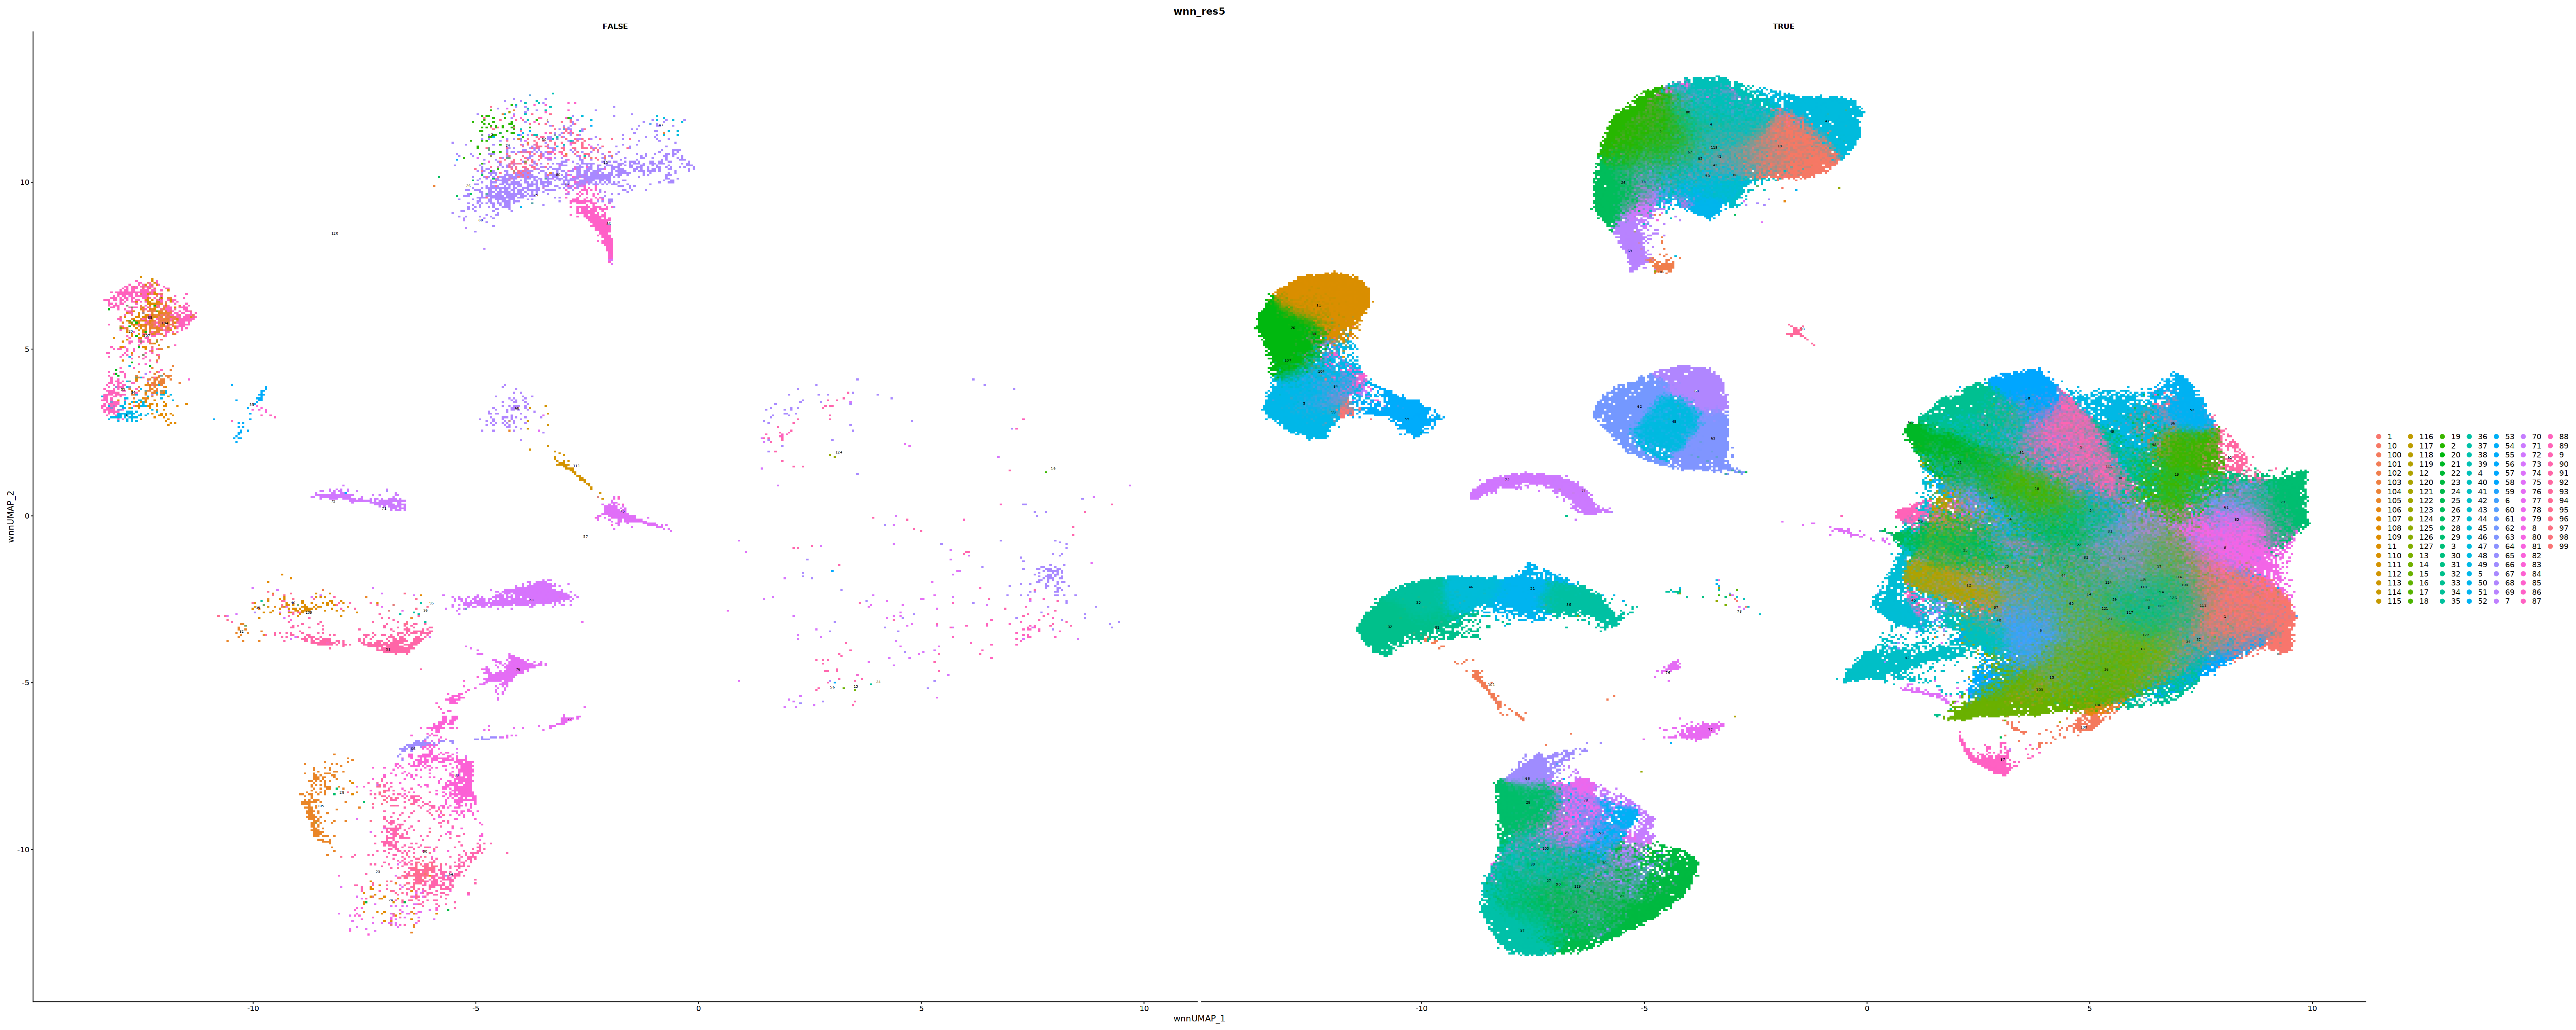

In [26]:
options(repr.plot.width=60, repr.plot.height=24)
p1 <- DimPlot(adata, reduction='umap.wnn', group.by='wnn_res5', split.by='keep', label=TRUE, label.size=2, repel=TRUE)
p1

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



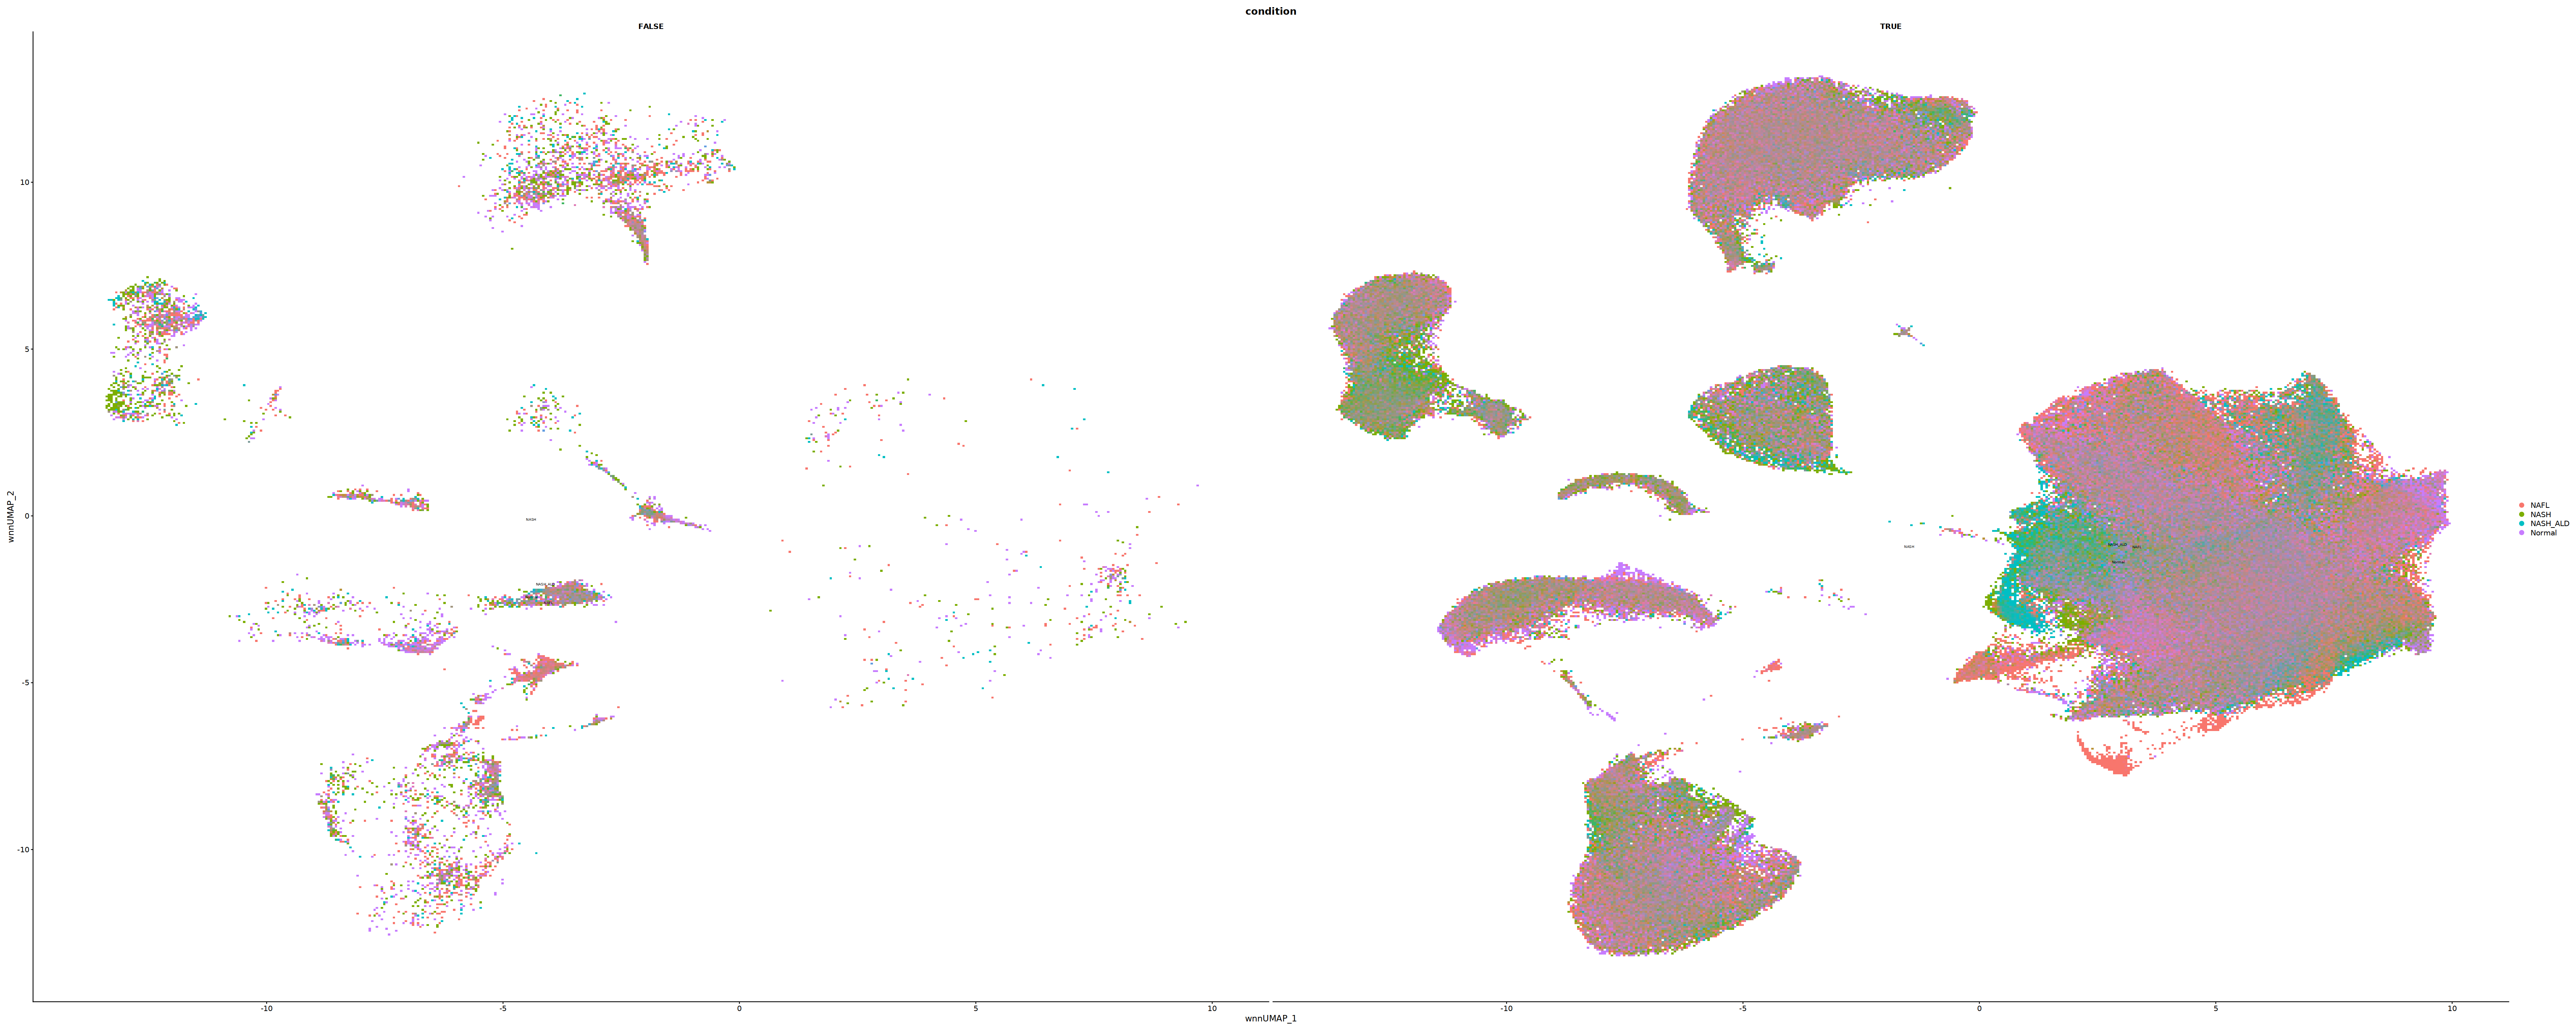

In [35]:
options(repr.plot.width=60, repr.plot.height=24)
p1 <- DimPlot(adata, reduction='umap.wnn', group.by='condition', split.by='keep', label=TRUE, label.size=2, repel=TRUE)
p1

In [32]:
colnames(adata[[]])

[1] "orig.ident"                        "nCount_RNA"                       
 [3] "nFeature_RNA"                      "percent.mt"                       
 [5] "nCount_RNA_raw"                    "nFeature_RNA_raw"                 
 [7] "nCount_ATAC"                       "nFeature_ATAC"                    
 [9] "donor_demux"                       "nCount_SCT"                       
[11] "nFeature_SCT"                      "SCT.weight"                       
[13] "ATAC.weight"                       "wsnn_res.0.2"                     
[15] "seurat_clusters"                   "log_nCount_ATAC"                  
[17] "log_nCount_SCT"                    "log_nFeature_ATAC"                
[19] "log_nFeature_SCT"                  "lane"                             
[21] "batch"                             "nCount_windows"                   
[23] "nFeature_windows"                  "gex_raw_reads"                    
[25] "gex_mapped_reads"                  "gex_conf_intergenic_reads"        
[27] "gex_conf_exonic_reads"             "gex_conf_intronic_reads"          
[29] "gex_conf_exonic_unique_reads"      "gex_conf_exonic_antisense_reads"  
[31] "gex_conf_exonic_dup_reads"         "gex_exonic_umis"                  
[33] "gex_conf_intronic_unique_reads"    "gex_conf_intronic_antisense_reads"
[35] "gex_conf_intronic_dup_reads"       "gex_intronic_umis"                
[37] "gex_conf_txomic_unique_reads"      "gex_umis_count"                   
[39] "gex_genes_count"                   "atac_raw_reads"                   
[41] "atac_unmapped_reads"               "atac_lowmapq"                     
[43] "atac_dup_reads"                    "atac_chimeric_reads"              
[45] "atac_mitochondrial_reads"          "atac_fragments"                   
[47] "atac_TSS_fragments"                "atac_peak_region_fragments"       
[49] "atac_peak_region_cutsites"         "TSS.enrichment"                   
[51] "TSS.percentile"                    "condition"                        
[53] "disease_status"                    "library"                          
[55] "windows.weight"                    "wsnn_res.0.25"                    
[57] "amulet"                            "wsnn_res.0.5"                     
[59] "wnn_res1"                          "wnn_res2"                         
[61] "wnn_res10"                         "wnn_res20"                        
[63] "wnn_res15"                         "wnn_res5"                         
[65] "keep"                              "keep_bc"                          
[67] "no_keep_bc"